# 🔤 Odia ↔ Hindi Neural Machine Translator
### Transformer-Based Seq2Seq with Morphological Preprocessing

---

## 📋 Pipeline Overview

```
RAW PARALLEL CORPUS (Odia ↔ Hindi)
         │
         ▼
┌─────────────────────────────┐
│   STAGE 1: DATA LOADING     │  → Load from HuggingFace / Kaggle CSV
│   & CLEANING                │  → Drop nulls, duplicates, reset index
└────────────┬────────────────┘
             ▼
┌─────────────────────────────┐
│   STAGE 2: TEXT             │  → HTML tag removal
│   PREPROCESSING             │  → Unicode normalization (NFC)
│                             │  → Remove invalid chars
│                             │  → Danda / Double-Danda management
│                             │  → English word detection & removal
│                             │  → Length filtering
└────────────┬────────────────┘
             ▼
┌─────────────────────────────┐
│   STAGE 3: MORPHOLOGICAL    │  → Morfessor unsupervised segmentation
│   ANALYSIS                  │  → Applied to both Odia & Hindi
│                             │  → Handles agglutinative morphology
└────────────┬────────────────┘
             ▼
┌─────────────────────────────┐
│   STAGE 4: VOCABULARY       │  → Build vocab from morphemes
│   BUILDING                  │  → Special tokens: <pad>,<sos>,<eos>,<unk>
│                             │  → Frequency-based filtering
└────────────┬────────────────┘
             ▼
┌─────────────────────────────┐
│   STAGE 5: TOKENIZATION     │  → Integer encoding
│   & DATASET                 │  → Padding & masking
│                             │  → Train / Val / Test split (70/15/15)
└────────────┬────────────────┘
             ▼
┌─────────────────────────────┐
│   STAGE 6: TRANSFORMER      │  → Embedding + Positional Encoding
│   MODEL                     │  → Multi-Head Self-Attention (Encoder)
│                             │  → Multi-Head Self + Cross Attention (Decoder)
│                             │  → Xavier weight initialization
│                             │  → Label smoothing loss
└────────────┬────────────────┘
             ▼
┌─────────────────────────────┐
│   STAGE 7: TRAINING         │  → Warmup LR scheduler
│                             │  → Gradient clipping
│                             │  → Early stopping (patience-based)
│                             │  → Checkpoint saving/resuming
└────────────┬────────────────┘
             ▼
┌─────────────────────────────┐
│   STAGE 8: EVALUATION       │  → BLEU-1/2/3/4
│   & METRICS                 │  → ChrF Score
│                             │  → TER Score
│                             │  → Back-Translation Check (Hi→Or→Hi)
└────────────┬────────────────┘
             ▼
┌─────────────────────────────┐
│   STAGE 9: INFERENCE        │  → Beam Search with Temperature
│   & TRANSLATION             │  → Length Penalty
│                             │  → Interactive Translation
└─────────────────────────────┘
```

**Dataset**: 124,000 parallel Odia-Hindi sentence pairs  
**Hardware**: Kaggle GPU (T4/P100)  
**Architecture**: Transformer (6L encoder + 6L decoder, 512d)

## Cell 1 — Install Dependencies

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1: INSTALL DEPENDENCIES
# ─────────────────────────────────────────────────────────────────────────────
import subprocess, sys

packages = [
    'morfessor',
    'sacrebleu',
    'sacremoses',
    'datasets',          # HuggingFace datasets
    'indic-nlp-library', # fallback Indic NLP
    'tqdm',
    'seaborn',
    'matplotlib',
    'scikit-learn',
]

for pkg in packages:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=False)

print('✅ All packages installed!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 9.9 MB/s eta 0:00:00
✅ All packages installed!


## Cell 2 — Imports & Device Setup

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2: IMPORTS & DEVICE SETUP
# ─────────────────────────────────────────────────────────────────────────────
import os, re, math, time, json, html, pickle, random, unicodedata, copy
from collections import Counter
from typing import List, Dict, Tuple, Optional
from functools import lru_cache
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torch.optim.lr_scheduler import LambdaLR

from sklearn.model_selection import train_test_split

import morfessor
import sacrebleu
from sacrebleu.metrics import BLEU, CHRF, TER

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# ── Device ───────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# ── Plotting style ───────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'figure.dpi': 100,
    'font.size': 12,
})
print('✅ Imports done!')

🖥️  Device: cuda
   GPU: Tesla P100-PCIE-16GB
   VRAM: 17.1 GB
✅ Imports done!


## Cell 3 — Configuration

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3: CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
class Config:
    """Single source of truth for all hyperparameters."""

    # ── Paths ─────────────────────────────────────────────────────────────────
    OUTPUT_DIR  = '/kaggle/working/outputs'
    CKPT_DIR    = '/kaggle/working/checkpoints'
    MODEL_DIR   = '/kaggle/working/models'
    MORPH_DIR   = '/kaggle/working/morph_models'

    # ── Languages ─────────────────────────────────────────────────────────────
    SRC_LANG = 'or'
    TGT_LANG = 'hi'

    # ── Preprocessing ─────────────────────────────────────────────────────────
    MIN_LEN          = 2
    MAX_LEN          = 100
    REMOVE_ENG_WORDS = True
    USE_MORPH        = True
    MORPH_EPOCHS     = 8     # FIX: was 4 — too few for proper segmentation

    # ── Vocabulary ────────────────────────────────────────────────────────────
    # FIX: increased from 16k→32k and MIN_FREQ 2→1
    # Previous 16k vocab gave only 89% Odia coverage → too many <unk> outputs
    SRC_VOCAB_SIZE = 32000
    TGT_VOCAB_SIZE = 32000
    MIN_FREQ       = 1       # FIX: was 2 — words like ଡ଼ାଲ,ସୁଆଦ were excluded

    # ── Dataset ───────────────────────────────────────────────────────────────
    TARGET_N_PAIRS  = 200000  # FIX: was 124k — use more of samanantar's 1.3M

    # ── Special tokens ────────────────────────────────────────────────────────
    PAD = '<pad>'
    SOS = '<sos>'
    EOS = '<eos>'
    UNK = '<unk>'

    # ── Data split ────────────────────────────────────────────────────────────
    VAL_RATIO  = 0.15
    TEST_RATIO = 0.15

    # ── Model architecture ────────────────────────────────────────────────────
    D_MODEL         = 256
    N_HEADS         = 8
    N_ENC_LAYERS    = 4
    N_DEC_LAYERS    = 4
    D_FF            = 1024
    DROPOUT         = 0.3
    MAX_POS_ENC     = 512

    # ── Training ──────────────────────────────────────────────────────────────
    BATCH_SIZE      = 64
    MAX_EPOCHS      = 30
    WARMUP_STEPS    = 4000
    GRAD_CLIP       = 1.0
    LABEL_SMOOTH    = 0.1
    ACCUMULATE_GRAD = 4    # FIX: was 2 — effective batch=256 for better convergence

    # ── Early stopping ────────────────────────────────────────────────────────
    PATIENCE        = 8   # FIX: was 8 — model was stopped too early (epoch 8)
    MIN_DELTA       = 1e-4

    # ── Checkpointing ─────────────────────────────────────────────────────────
    SAVE_EVERY      = 1
    KEEP_LAST_N     = 3

    # ── Beam search ───────────────────────────────────────────────────────────
    BEAM_SIZE       = 5
    TEMPERATURE     = 1.0
    LENGTH_PENALTY  = 0.6
    MAX_DECODE_LEN  = 128

    @classmethod
    def make_dirs(cls):
        for d in [cls.OUTPUT_DIR, cls.CKPT_DIR, cls.MODEL_DIR, cls.MORPH_DIR]:
            os.makedirs(d, exist_ok=True)

    @classmethod
    def summary(cls):
        print('\n' + '='*55)
        print('  CONFIGURATION SUMMARY')
        print('='*55)
        attrs = {k: v for k, v in vars(cls).items()
                 if not k.startswith('_') and not callable(v)}
        for k, v in attrs.items():
            print(f'  {k:<24} = {v}')
        print('='*55)

Config.make_dirs()
Config.summary()



  CONFIGURATION SUMMARY
  OUTPUT_DIR               = /kaggle/working/outputs
  CKPT_DIR                 = /kaggle/working/checkpoints
  MODEL_DIR                = /kaggle/working/models
  MORPH_DIR                = /kaggle/working/morph_models
  SRC_LANG                 = or
  TGT_LANG                 = hi
  MIN_LEN                  = 2
  MAX_LEN                  = 100
  REMOVE_ENG_WORDS         = True
  USE_MORPH                = True
  MORPH_EPOCHS             = 8
  SRC_VOCAB_SIZE           = 32000
  TGT_VOCAB_SIZE           = 32000
  MIN_FREQ                 = 1
  TARGET_N_PAIRS           = 200000
  PAD                      = <pad>
  SOS                      = <sos>
  EOS                      = <eos>
  UNK                      = <unk>
  VAL_RATIO                = 0.15
  TEST_RATIO               = 0.15
  D_MODEL                  = 256
  N_HEADS                  = 8
  N_ENC_LAYERS             = 4
  N_DEC_LAYERS             = 4
  D_FF                     = 1024
  DROPOUT              

## Cell 4 — Script Ranges & Unicode Utilities (from langinfo.py)

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4: SCRIPT / UNICODE UTILITIES
# Extracted & adapted from langinfo.py + indic_scripts.py
# ─────────────────────────────────────────────────────────────────────────────

# Unicode block ranges for relevant scripts
SCRIPT_RANGES = {
    'or': [0x0B00, 0x0B7F],  # Odia (Oriya)
    'hi': [0x0900, 0x097F],  # Devanagari (Hindi, Marathi, etc.)
    'bn': [0x0980, 0x09FF],  # Bengali
    'ta': [0x0B80, 0x0BFF],  # Tamil
    'te': [0x0C00, 0x0C7F],  # Telugu
    'kn': [0x0C80, 0x0CFF],  # Kannada
    'ml': [0x0D00, 0x0D7F],  # Malayalam
    'gu': [0x0A80, 0x0AFF],  # Gujarati
    'pa': [0x0A00, 0x0A7F],  # Punjabi (Gurmukhi)
}

DANDA       = 0x0964  # ।
DOUBLE_DANDA = 0x0965  # ॥
DANDA_CHAR  = chr(DANDA)
DOUBLE_DANDA_CHAR = chr(DOUBLE_DANDA)

# Odia-specific characters
ODIA_NUMERALS_RANGE  = (0x0B66, 0x0B6F)   # ୦-୯
ODIA_HALANTA         = 0x0B4D
ODIA_ANUSVARA        = 0x0B02
ODIA_VISARGA         = 0x0B03

# Hindi (Devanagari)-specific characters
HINDI_NUMERALS_RANGE = (0x0966, 0x096F)   # ०-९
HINDI_HALANTA        = 0x094D
HINDI_NUKTA          = 0x093C

class ScriptUtils:
    """Utility functions for Indic script character classification."""

    @staticmethod
    def get_offset(char: str, lang: str) -> int:
        """Return the script-relative offset of a character."""
        if lang not in SCRIPT_RANGES:
            return -1
        return ord(char) - SCRIPT_RANGES[lang][0]

    @staticmethod
    def is_in_script(char: str, lang: str) -> bool:
        """Check if character belongs to the script of the given language."""
        if lang not in SCRIPT_RANGES:
            return False
        lo, hi = SCRIPT_RANGES[lang]
        cp = ord(char)
        return (lo <= cp <= hi) or cp == DANDA or cp == DOUBLE_DANDA

    @staticmethod
    def is_odia_char(char: str) -> bool:
        cp = ord(char)
        return 0x0B00 <= cp <= 0x0B7F

    @staticmethod
    def is_hindi_char(char: str) -> bool:
        cp = ord(char)
        return 0x0900 <= cp <= 0x097F

    @staticmethod
    def is_latin_char(char: str) -> bool:
        cp = ord(char)
        return (0x0041 <= cp <= 0x005A) or (0x0061 <= cp <= 0x007A)

    @staticmethod
    def is_digit(char: str) -> bool:
        cp = ord(char)
        # ASCII digits + Odia digits + Devanagari digits
        return (0x0030 <= cp <= 0x0039) or \
               (ODIA_NUMERALS_RANGE[0] <= cp <= ODIA_NUMERALS_RANGE[1]) or \
               (HINDI_NUMERALS_RANGE[0] <= cp <= HINDI_NUMERALS_RANGE[1])

    @staticmethod
    def odia_numeral_to_ascii(text: str) -> str:
        """Convert Odia numerals ୦-୯ to ASCII 0-9."""
        result = []
        for ch in text:
            cp = ord(ch)
            if ODIA_NUMERALS_RANGE[0] <= cp <= ODIA_NUMERALS_RANGE[1]:
                result.append(str(cp - ODIA_NUMERALS_RANGE[0]))
            else:
                result.append(ch)
        return ''.join(result)

    @staticmethod
    def hindi_numeral_to_ascii(text: str) -> str:
        """Convert Devanagari numerals ०-९ to ASCII 0-9."""
        result = []
        for ch in text:
            cp = ord(ch)
            if HINDI_NUMERALS_RANGE[0] <= cp <= HINDI_NUMERALS_RANGE[1]:
                result.append(str(cp - HINDI_NUMERALS_RANGE[0]))
            else:
                result.append(ch)
        return ''.join(result)

print('✅ ScriptUtils loaded')
# Quick verification
print(f'  Odia "ଓ" in Odia script: {ScriptUtils.is_odia_char("ଓ")}')
print(f'  Hindi "ह" in Hindi script: {ScriptUtils.is_hindi_char("ह")}')
print(f'  "A" is Latin: {ScriptUtils.is_latin_char("A")}')

✅ ScriptUtils loaded
  Odia "ଓ" in Odia script: True
  Hindi "ह" in Hindi script: True
  "A" is Latin: True


## Cell 5 — Text Preprocessing Classes

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5: TEXT PREPROCESSING
# Covers: HTML removal, Unicode normalization, danda management,
#         English word removal/replacement, noise removal
# ─────────────────────────────────────────────────────────────────────────────

class TextCleaner:
    """
    Comprehensive text cleaner for Indic language (Odia / Hindi) corpora.
    All cleaning steps are deterministic and chainable.
    """

    # ── Compiled regex patterns ───────────────────────────────────────────────
    _RE_HTML_TAG      = re.compile(r'<[^>]+>')
    _RE_HTML_ENTITY   = re.compile(r'&[a-zA-Z0-9#]+;')
    _RE_URL           = re.compile(r'https?://\S+|www\.\S+')
    _RE_EMAIL         = re.compile(r'\S+@\S+\.\S+')
    _RE_HASHTAG       = re.compile(r'#\w+')
    _RE_MENTION       = re.compile(r'@\w+')
    _RE_MULTI_SPACE   = re.compile(r'[ \t]+')
    _RE_MULTI_NL      = re.compile(r'\n{2,}')
    # English word pattern: 2+ consecutive Latin characters
    _RE_ENG_WORD      = re.compile(r'\b[A-Za-z]{2,}\b')
    _RE_PURE_ASCII    = re.compile(r'^[\x00-\x7F]+$')
    # Punctuation to normalize
    _RE_PUNCT_NORM    = re.compile(r'[!?]+')  # normalize repeated !?
    _RE_DANDA         = re.compile(r'[।\|]+')   # normalize | to danda
    _RE_DOUBLE_DANDA  = re.compile(r'॥+')
    # Digits that should be kept as-is (numbers mixed with script chars)
    _RE_LONE_DIGIT    = re.compile(r'^\d+$')

    def __init__(
        self,
        lang: str,
        remove_eng_words: bool = True,
        normalize_dandas: bool = True,
        keep_numerals:    bool = True,
    ):
        self.lang = lang
        self.remove_eng_words = remove_eng_words
        self.normalize_dandas = normalize_dandas
        self.keep_numerals = keep_numerals
        # Script validator
        self._is_script_char = (
            ScriptUtils.is_odia_char if lang == 'or'
            else ScriptUtils.is_hindi_char
        )

    def remove_html(self, text: str) -> str:
        """Remove HTML tags and decode HTML entities."""
        text = self._RE_HTML_TAG.sub(' ', text)
        text = html.unescape(text)
        text = self._RE_HTML_ENTITY.sub(' ', text)
        return text

    def normalize_unicode(self, text: str) -> str:
        """Apply Unicode NFC normalization."""
        return unicodedata.normalize('NFC', text)

    def remove_noise(self, text: str) -> str:
        """Remove URLs, emails, hashtags, mentions."""
        text = self._RE_URL.sub(' ', text)
        text = self._RE_EMAIL.sub(' ', text)
        text = self._RE_HASHTAG.sub(' ', text)
        text = self._RE_MENTION.sub(' ', text)
        return text

    def handle_dandas(self, text: str) -> str:
        """
        Normalize danda (।) and double-danda (॥) usage.
        - Replaces | with danda for Odia/Hindi
        - Ensures single space around dandas
        - Converts sentence-ending danda to period for easier tokenization
        """
        if not self.normalize_dandas:
            return text
        # Normalize pipe to danda
        text = re.sub(r'\|', '।', text)
        # Collapse multiple dandas
        text = self._RE_DOUBLE_DANDA.sub('॥', text)
        text = self._RE_DANDA.sub('।', text)
        # Add space before danda if missing
        text = re.sub(r'([^\s])([।॥])', r'\1 \2', text)
        text = re.sub(r'([।॥])([^\s])', r'\1 \2', text)
        # Replace danda with period for uniformity
        text = text.replace('।', '.').replace('॥', '.')
        return text

    def remove_english_words(self, text: str) -> str:
        """
        Remove purely English (Latin-alphabet) words from Indic text.
        Single Latin letters (like 'a') are also removed.
        """
        if not self.remove_eng_words:
            return text
        # Remove English words (2+ chars)
        text = self._RE_ENG_WORD.sub(' ', text)
        # Remove lone single Latin chars
        text = re.sub(r'\b[A-Za-z]\b', ' ', text)
        return text

    def remove_invalid_chars(self, text: str) -> str:
        """
        Keep only:
          - Characters in the target Indic script
          - Common punctuation: . , ? ! ( ) " '
          - Digits (ASCII and native)
          - Whitespace
        """
        result = []
        for ch in text:
            cp = ord(ch)
            keep = (
                self._is_script_char(ch) or
                ch in ' .,?!()"\'-:;' or
                ch.isdigit() or
                cp == DANDA or cp == DOUBLE_DANDA or
                ch in '।॥' or
                ch == '\n'
            )
            if keep:
                result.append(ch)
        return ''.join(result)

    def normalize_whitespace(self, text: str) -> str:
        """Collapse multiple spaces/tabs into a single space."""
        text = self._RE_MULTI_SPACE.sub(' ', text)
        return text.strip()

    def normalize_punctuation(self, text: str) -> str:
        """Normalize repeated punctuation."""
        text = self._RE_PUNCT_NORM.sub(lambda m: m.group(0)[0], text)
        return text

    def clean(self, text: str) -> str:
        """
        Full cleaning pipeline. Returns cleaned text.
        Returns empty string if input is None or non-string.
        """
        if not isinstance(text, str) or not text.strip():
            return ''
        text = self.remove_html(text)
        text = self.normalize_unicode(text)
        text = self.remove_noise(text)
        text = self.handle_dandas(text)
        text = self.remove_english_words(text)
        text = self.remove_invalid_chars(text)
        text = self.normalize_punctuation(text)
        text = self.normalize_whitespace(text)
        return text


# ── Standalone test ───────────────────────────────────────────────────────────
print('✅ TextCleaner loaded')
_oc = TextCleaner(lang='or')
_hc = TextCleaner(lang='hi')
_test_or = '<p>ନମସ୍କାର! This is a test।</p>'
_test_hi = '<b>नमस्ते</b> Hello World! यह एक परीक्षण है।'
print(f'  Odia clean : {_oc.clean(_test_or)}')
print(f'  Hindi clean: {_hc.clean(_test_hi)}')

✅ TextCleaner loaded
  Odia clean : ନମସ୍କାର! .
  Hindi clean: नमस्ते ! यह एक परीक्षण है .


## Cell 6 — Data Loading & Cleaning

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6a: DATASET STRUCTURE DIAGNOSTIC (optional — run once to inspect)
# ─────────────────────────────────────────────────────────────────────────────
from datasets import load_dataset

print('Loading 1 row from Anudesh to inspect structure...\n')
ds_sample = load_dataset('ai4bharat/indic-align', 'Anudesh', split='train')
row = ds_sample[0]

print('=== TOP-LEVEL KEYS ===')
print(list(row.keys()))
print()

print('=== interactions DEEP DIVE ===')
interactions = row.get('interactions', [])
print(f'Type of interactions: {type(interactions)}, Length: {len(interactions)}')
print()
for ti, turn in enumerate(interactions[:2]):
    print(f'--- Turn {ti} ---')
    items = turn if isinstance(turn, list) else [turn]
    for si, item in enumerate(items[:2]):
        print(f'  item[{si}] type={type(item).__name__}')
        if isinstance(item, dict):
            for k, v in item.items():
                print(f'    [{k}]: {str(v)[:100]}')
    print()

print('=== DATASET SCHEMA ===')
print(ds_sample.features)


Loading 1 row from Anudesh to inspect structure...



README.md: 0.00B [00:00, ?B/s]

indicalign-instruct/anudesh/anudesh1.par(…):   0%|          | 0.00/42.2M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

=== TOP-LEVEL KEYS ===
['id', 'interactions', 'num_turns']

=== interactions DEEP DIVE ===
Type of interactions: <class 'list'>, Length: 1

--- Turn 0 ---
  item[0] type=str
  item[1] type=str

=== DATASET SCHEMA ===
{'id': Value('string'), 'interactions': List(List(Value('string'))), 'num_turns': Value('int64')}


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6b-preview: RAW DATA PREVIEW (run to verify columns before loading)
# samanantar 'or' split: src=English, tgt=Odia
# samanantar 'hi' split: src=English, tgt=Hindi
# The loader pivots via English to get Odia-Hindi pairs.
# ─────────────────────────────────────────────────────────────────────────────
from datasets import load_dataset

print('=== ai4bharat/samanantar or-split (first 3 rows) ===')
ds_or = load_dataset('ai4bharat/samanantar', 'or', split='train')
for i in range(3):
    print(f'  src (English): {ds_or[i]["src"]}')
    print(f'  tgt (Odia)  : {ds_or[i]["tgt"]}')
    print()

print('=== ai4bharat/samanantar hi-split (first 3 rows) ===')
ds_hi = load_dataset('ai4bharat/samanantar', 'hi', split='train')
for i in range(3):
    print(f'  src (English): {ds_hi[i]["src"]}')
    print(f'  tgt (Hindi) : {ds_hi[i]["tgt"]}')
    print()


=== ai4bharat/samanantar or-split (first 3 rows) ===


README.md: 0.00B [00:00, ?B/s]

or/train-00000-of-00001.parquet:   0%|          | 0.00/136M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/998228 [00:00<?, ? examples/s]

  src (English): The Congress, however, has also not announced its candidates so far.
  tgt (Odia)  : ଅଥଚ ବଡ଼ଚଣାର କଂଗ୍ରେସ ପ୍ରାର୍ଥୀ ଆଜି ପର୍ଯ୍ୟନ୍ତ ଘୋଷଣା କରାଯାଇପାରି ନାହିଁ।

  src (English): Modi said, hitting out at Naidu.
  tgt (Odia)  : ମୋଦିଙ୍କୁ ଆକ୍ଷେପ କରି ଗଡକରି ଏହା କହିଛନ୍ତି ।

  src (English): The government cannot waive it off.
  tgt (Odia)  : ସରକାର ଚାହିଲେ ବି ଏହାକୁ ଏଡ଼ାଇ ପାରିବେ ନାହିଁ।

=== ai4bharat/samanantar hi-split (first 3 rows) ===


...

hi/train-00005-of-00008.parquet:   0%|          | 0.00/239M [00:00<?, ?B/s]

hi/train-00006-of-00008.parquet:   0%|          | 0.00/239M [00:00<?, ?B/s]

hi/train-00007-of-00008.parquet:   0%|          | 0.00/240M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10125706 [00:00<?, ? examples/s]

  src (English): However, Paes, who was partnering Australia's Paul Hanley, could only go as far as the quarterfinals where they lost to Bhupathi and Knowles
  tgt (Hindi) : आस्ट्रेलिया के पाल हेनली के साथ जोड़ी बनाने वाले पेस मियामी में क्वार्टरफाइनल तक ही पहुंच सके क्योंकि इस दौर में उन्हें भूपति और नोल्स ने हराया था।

  src (English): Whosoever desires the reward of the world, with Allah is the reward of the world and of the Everlasting Life. Allah is the Hearer, the Seer.
  tgt (Hindi) : और जो शख्स (अपने आमाल का) बदला दुनिया ही में चाहता है तो ख़ुदा के पास दुनिया व आख़िरत दोनों का अज्र मौजूद है और ख़ुदा तो हर शख्स की सुनता और सबको देखता है

  src (English): The value of insects in the biosphere is enormous because they outnumber all other living groups in measure of species richness.
  tgt (Hindi) : जैव-मंडल में कीड़ों का मूल्य बहुत है, क्योंकि प्रजातियों की समृद्धि के मामले में उनकी संख्या अन्य जीव समूहों से ज़्यादा है।



In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6c: DATA LOADING — Multi-source Odia–Hindi parallel corpus
# Sources (tried in order, failures skipped gracefully):
#   1. ai4bharat/samanantar  — English pivot → Odia-Hindi (~1.3M en-or pairs)
#   2. Helsinki-NLP/opus-100 — direct or-hi pairs
#   3. facebook/flores200    — high-quality dev/devtest (~1k pairs each)
#
# SCRIPT VALIDATION: every pair is checked to ensure
#   odia column = Odia script (0x0B00-0x0B7F)
#   hindi column = Devanagari script (0x0900-0x097F)
# This prevents column-swap bugs from silently poisoning training.
# ─────────────────────────────────────────────────────────────────────────────

from datasets import load_dataset


def _has_script(text: str, lo: int, hi: int, threshold: float = 0.3) -> bool:
    """
    Return True if at least `threshold` fraction of alphabetic chars
    in text fall within the Unicode range [lo, hi].
    Used to validate Odia (0x0B00-0x0B7F) and Hindi (0x0900-0x097F) columns.
    """
    chars = [c for c in text if c.isalpha()]
    if not chars:
        return False
    count = sum(1 for c in chars if lo <= ord(c) <= hi)
    return (count / len(chars)) >= threshold


def _is_odia(text: str) -> bool:
    return _has_script(text, 0x0B00, 0x0B7F)


def _is_hindi(text: str) -> bool:
    return _has_script(text, 0x0900, 0x097F)


def _validate_pairs(pairs, name=''):
    """
    Filter pairs to ensure:
      col[0] = Odia script
      col[1] = Hindi/Devanagari script
    Logs how many were dropped for wrong script.
    """
    before = len(pairs)
    valid = [(o, h) for o, h in pairs if _is_odia(o) and _is_hindi(h)]
    dropped = before - len(valid)
    if dropped > 0:
        print(f'     ⚠️  [{name}] Script validation dropped {dropped:,} pairs '
              f'({dropped/max(before,1)*100:.1f}%)')
    return valid


class SentenceSplitter:
    """Split multi-sentence Indic text into individual sentences."""
    _RE_SPLIT = re.compile(r'[।॥]|(?<=[^\d])\.(?=\s|$)|\n')
    _RE_LIST  = re.compile(r'^\s*[\u0B66-\u0B6F\u0966-\u096F0-9]+[.):]\s*')

    @classmethod
    def split(cls, text: str, min_chars: int = 8, max_chars: int = 400) -> List[str]:
        if not text or not isinstance(text, str):
            return []
        results = []
        for line in text.splitlines():
            line = cls._RE_LIST.sub('', line).strip()
            if not line:
                continue
            for part in cls._RE_SPLIT.split(line):
                part = part.strip().strip('।॥.,;:()')
                if min_chars <= len(part) <= max_chars:
                    results.append(part)
        return results


class IndicParallelLoader:
    """
    Loads Odia–Hindi parallel pairs from multiple HuggingFace sources.
    All sources validated for correct Odia/Hindi script assignment.
    """

    def __init__(self, config):
        self.cfg         = config
        self.odia_clean  = TextCleaner(lang='or', remove_eng_words=config.REMOVE_ENG_WORDS)
        self.hindi_clean = TextCleaner(lang='hi', remove_eng_words=config.REMOVE_ENG_WORDS)

    def _load_samanantar(self) -> List[Tuple[str, str]]:
        """
        Pivot via English:
          en→or pairs + en→hi pairs  →  align by English key  →  or–hi pairs
        """
        print('  📥 ai4bharat/samanantar (en-or + en-hi pivot)...', end=' ', flush=True)
        try:
            ds_or = load_dataset('ai4bharat/samanantar', 'or', split='train')
            ds_hi = load_dataset('ai4bharat/samanantar', 'hi', split='train')

            # Build English→Odia lookup
            en_to_or: Dict[str, str] = {}
            for row in ds_or:
                en  = str(row.get('src') or '').strip()
                or_ = str(row.get('tgt') or '').strip()
                if en and or_:
                    en_to_or[en] = or_

            # Match English→Hindi rows to get Odia–Hindi pairs
            pairs = []
            for row in ds_hi:
                en = str(row.get('src') or '').strip()
                hi = str(row.get('tgt') or '').strip()
                if en and hi and en in en_to_or:
                    pairs.append((en_to_or[en], hi))

            pairs = _validate_pairs(pairs, 'samanantar')
            print(f'{len(pairs):,} valid pairs')
            return pairs
        except Exception as e:
            print(f'FAILED: {e}')
            return []

    def _load_opus100(self) -> List[Tuple[str, str]]:
        """Helsinki-NLP/opus-100 or-hi direct pairs."""
        print('  📥 Helsinki-NLP/opus-100 (or-hi)...', end=' ', flush=True)
        try:
            ds = load_dataset('Helsinki-NLP/opus-100', 'or-hi', split='train')
            pairs = []
            for row in ds:
                trans = row.get('translation', {})
                src = str(trans.get('or') or '').strip()
                tgt = str(trans.get('hi') or '').strip()
                if src and tgt:
                    pairs.append((src, tgt))
            pairs = _validate_pairs(pairs, 'opus-100')
            print(f'{len(pairs):,} valid pairs')
            return pairs
        except Exception as e:
            print(f'FAILED: {e}')
            return []

    def _load_flores200(self) -> List[Tuple[str, str]]:
        """facebook/flores200 — high quality benchmark sentences."""
        print('  📥 facebook/flores200 (ory_Orya + hin_Deva)...', end=' ', flush=True)
        try:
            pairs = []
            for split in ['dev', 'devtest']:
                ds_or = load_dataset('facebook/flores200', 'ory_Orya', split=split)
                ds_hi = load_dataset('facebook/flores200', 'hin_Deva', split=split)
                for row_or, row_hi in zip(ds_or, ds_hi):
                    src = str(row_or.get('sentence') or '').strip()
                    tgt = str(row_hi.get('sentence') or '').strip()
                    if src and tgt:
                        pairs.append((src, tgt))
            pairs = _validate_pairs(pairs, 'flores200')
            print(f'{len(pairs):,} valid pairs')
            return pairs
        except Exception as e:
            print(f'FAILED: {e}')
            return []

    def load_all(self) -> pd.DataFrame:
        print('📂 Loading Odia–Hindi parallel corpora...\n')

        all_pairs: List[Tuple[str, str]] = []
        all_pairs.extend(self._load_samanantar())
        all_pairs.extend(self._load_opus100())
        all_pairs.extend(self._load_flores200())

        print(f'\n   Total validated pairs: {len(all_pairs):,}')

        if not all_pairs:
            raise RuntimeError(
                '\n\n❌ Zero pairs loaded!\n'
                'Check: Internet is ON in Kaggle session options.\n'
            )

        df = pd.DataFrame(all_pairs, columns=['odia', 'hindi'])
        df = df.dropna(subset=['odia', 'hindi'])

        # Clean text
        print('🧹 Cleaning...')
        df['odia']  = df['odia'].apply(self.odia_clean.clean)
        df['hindi'] = df['hindi'].apply(self.hindi_clean.clean)

        # Drop rows that became empty after cleaning
        df = df[(df['odia'].str.strip() != '') & (df['hindi'].str.strip() != '')]

        # Word lengths
        df['odia_len']  = df['odia'].str.split().str.len()
        df['hindi_len'] = df['hindi'].str.split().str.len()

        # Length filter
        before = len(df)
        df = df[
            (df['odia_len']  >= Config.MIN_LEN) & (df['odia_len']  <= Config.MAX_LEN) &
            (df['hindi_len'] >= Config.MIN_LEN) & (df['hindi_len'] <= Config.MAX_LEN)
        ]
        print(f'   Length filter: kept {len(df):,} / {before:,}')

        # Dedup
        df = df.drop_duplicates(subset=['odia', 'hindi'])
        df = df.drop_duplicates(subset=['odia'])

        # Shuffle and cap
        df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
        if len(df) > Config.TARGET_N_PAIRS:
            df = df.iloc[:Config.TARGET_N_PAIRS].reset_index(drop=True)

        df = df.reset_index(drop=True)

        print(f'\n✅ Final: {len(df):,} clean Odia–Hindi parallel pairs')
        print(f'   Odia  avg len: {df["odia_len"].mean():.1f} words')
        print(f'   Hindi avg len: {df["hindi_len"].mean():.1f} words')
        print('\nSample pairs:')
        for _, r in df.head(3).iterrows():
            print(f'  OR: {r["odia"]}')
            print(f'  HI: {r["hindi"]}')
            print()
        return df


hf_loader = IndicParallelLoader(Config)
df = hf_loader.load_all()


📂 Loading Odia–Hindi parallel corpora...

  📥 ai4bharat/samanantar (en-or + en-hi pivot)...      ⚠️  [samanantar] Script validation dropped 562 pairs (0.0%)
1,312,614 valid pairs
  📥 Helsinki-NLP/opus-100 (or-hi)... 

README.md: 0.00B [00:00, ?B/s]

FAILED: BuilderConfig 'or-hi' not found. Available: ['af-en', 'am-en', 'an-en', 'ar-de', 'ar-en', 'ar-fr', 'ar-nl', 'ar-ru', 'ar-zh', 'as-en', 'az-en', 'be-en', 'bg-en', 'bn-en', 'br-en', 'bs-en', 'ca-en', 'cs-en', 'cy-en', 'da-en', 'de-en', 'de-fr', 'de-nl', 'de-ru', 'de-zh', 'dz-en', 'el-en', 'en-eo', 'en-es', 'en-et', 'en-eu', 'en-fa', 'en-fi', 'en-fr', 'en-fy', 'en-ga', 'en-gd', 'en-gl', 'en-gu', 'en-ha', 'en-he', 'en-hi', 'en-hr', 'en-hu', 'en-hy', 'en-id', 'en-ig', 'en-is', 'en-it', 'en-ja', 'en-ka', 'en-kk', 'en-km', 'en-kn', 'en-ko', 'en-ku', 'en-ky', 'en-li', 'en-lt', 'en-lv', 'en-mg', 'en-mk', 'en-ml', 'en-mn', 'en-mr', 'en-ms', 'en-mt', 'en-my', 'en-nb', 'en-ne', 'en-nl', 'en-nn', 'en-no', 'en-oc', 'en-or', 'en-pa', 'en-pl', 'en-ps', 'en-pt', 'en-ro', 'en-ru', 'en-rw', 'en-se', 'en-sh', 'en-si', 'en-sk', 'en-sl', 'en-sq', 'en-sr', 'en-sv', 'en-ta', 'en-te', 'en-tg', 'en-th', 'en-tk', 'en-tr', 'en-tt', 'en-ug', 'en-uk', 'en-ur', 'en-uz', 'en-vi', 'en-wa', 'en-xh', 'en-yi', 'e

In [9]:
# CELL 6d: PREVIEW LOADED DATA — verify Odia and Hindi columns are correct
print('Odia should contain ଓଡ଼ିଆ script, Hindi should contain हिंदी script')
print()
for _, r in df.head(5).iterrows():
    print(f'  Odia : {r["odia"]}')
    print(f'  Hindi: {r["hindi"]}')
    print()
print(f'Total pairs: {len(df):,}')


Odia should contain ଓଡ଼ିଆ script, Hindi should contain हिंदी script

  Odia : ପ୍ରତିଦିନ ମା ଲକ୍ଷ୍ମୀଙ୍କୁ ଆରାଧନା କରନ୍ତୁ .
  Hindi: लक्ष्मी पूजा प्रतिदिन की जानी चाहिए-

  Odia : ମୁମ୍ବାଇ ଉତ୍ତର ଲୋକସଭା ନିର୍ବାଚନ ମଣ୍ଡଳୀରୁ ସେ ନିର୍ବାଚନ ଲଢ଼ିବେ ବୋଲି ଜଣାପଡ଼ିଛି .
  Hindi: वे कांग्रेस के टिकट पर मुम्बई नॉर्थ सीट से चुनाव लड़ रही हैं .

  Odia : କିନ୍ତୁ ଆମ୍ଭର ଜନ୍ମଭୂମି ହେଉଛି ସ୍ବର୍ଗ . ଆମେ ସ୍ବର୍ଗରୁ ଆମ୍ଭର ତ୍ରାଣକର୍ତ୍ତା ଯୀଶୁ ଖ୍ରୀଷ୍ଟଙ୍କ ଆଗମନକୁ ପ୍ରତୀକ୍ଷା କରୁଛୁ . ଯୀଶୁଖ୍ରୀଷ୍ଟ ଆମ୍ଭର ପରିତ୍ରାଣକର୍ତ୍ତା ପ୍ରଭୁ ଅଟନ୍ତି .
  Hindi: पर हमारा स्वदेश स्वर्ग पर है. और हम पर उद्धारकर्ता प्रभु यीशु मसीह के वहां से आन ही बाट जोह रहे हैं .

  Odia : ଏହା ମାଧ୍ୟମରେ ଯଦି ଆମେ ଗାଁର କଥା କହିବା ତ ପୂର୍ବ ସରକାରଙ୍କର ଶେଷ ଚାରି ବର୍ଷରେ ଗାଁରେ ସମଗ୍ର ହିନ୍ଦୁସ୍ଥାନରେ ପ୍ରାୟ ସାଢ଼େ 25 ଲକ୍ଷ ଘରର ନିର୍ମାଣ କରାଯାଇଥିଲା . ସେଠି ଆମ ସରକାର ବିଗତ ଚାରି ବର୍ଷରେ ଏକ କୋଟିରୁ ଅଧିକ ଘର ନିର୍ମାଣ କରିଛନ୍ତି .
  Hindi: इसी तरह यदि गांव की बात करें तो पिछली सरकार के अंतिम चार साल में गांव के अंदर पूरे हिन्दुस्तान में करीब-करीब साढे 25 लाख घरों का निर्माण किया गया था . वहीं हमारी सरकार ने 

## Cell 7 — Exploratory Data Analysis (EDA)

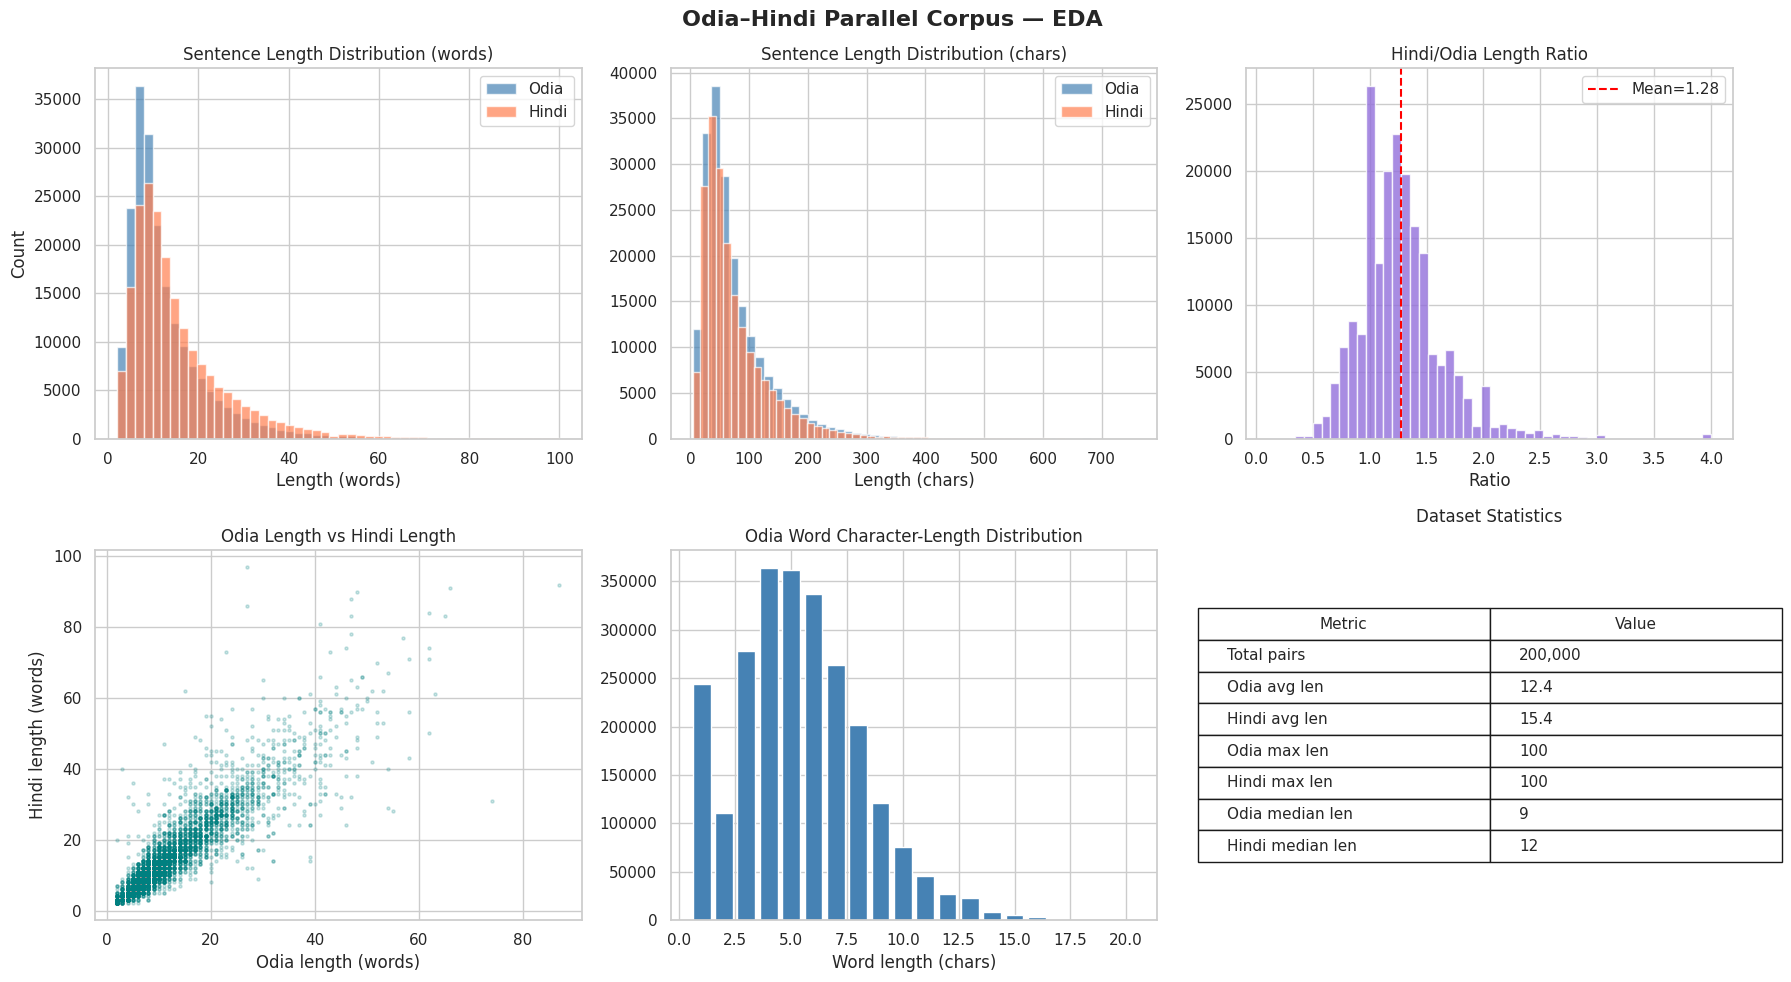

✅ EDA saved


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7: EXPLORATORY DATA ANALYSIS
# ─────────────────────────────────────────────────────────────────────────────

def plot_eda(df: pd.DataFrame):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Odia–Hindi Parallel Corpus — EDA', fontsize=16, fontweight='bold')

    # ── 1. Word length distributions ──────────────────────────────────────────
    axes[0, 0].hist(df['odia_len'],  bins=50, color='steelblue', alpha=0.7, label='Odia')
    axes[0, 0].hist(df['hindi_len'], bins=50, color='coral',     alpha=0.7, label='Hindi')
    axes[0, 0].set_title('Sentence Length Distribution (words)')
    axes[0, 0].set_xlabel('Length (words)')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].legend()

    # ── 2. Character length ────────────────────────────────────────────────────
    df_chars = df.copy()
    df_chars['odia_chars']  = df['odia'].str.len()
    df_chars['hindi_chars'] = df['hindi'].str.len()
    axes[0, 1].hist(df_chars['odia_chars'],  bins=50, color='steelblue', alpha=0.7, label='Odia')
    axes[0, 1].hist(df_chars['hindi_chars'], bins=50, color='coral',     alpha=0.7, label='Hindi')
    axes[0, 1].set_title('Sentence Length Distribution (chars)')
    axes[0, 1].set_xlabel('Length (chars)')
    axes[0, 1].legend()

    # ── 3. Length ratio ────────────────────────────────────────────────────────
    ratio = df['hindi_len'] / (df['odia_len'] + 1e-9)
    axes[0, 2].hist(ratio.clip(0, 4), bins=50, color='mediumpurple', alpha=0.8)
    axes[0, 2].axvline(ratio.mean(), color='red', linestyle='--', label=f'Mean={ratio.mean():.2f}')
    axes[0, 2].set_title('Hindi/Odia Length Ratio')
    axes[0, 2].set_xlabel('Ratio')
    axes[0, 2].legend()

    # ── 4. Scatter plot ────────────────────────────────────────────────────────
    sample = df.sample(min(5000, len(df)), random_state=42)
    axes[1, 0].scatter(sample['odia_len'], sample['hindi_len'],
                       alpha=0.2, s=5, color='teal')
    axes[1, 0].set_title('Odia Length vs Hindi Length')
    axes[1, 0].set_xlabel('Odia length (words)')
    axes[1, 0].set_ylabel('Hindi length (words)')

    # ── 5. Top Odia word lengths ───────────────────────────────────────────────
    odia_wl  = df['odia'].str.split().explode().str.len()
    odia_wl_counts = odia_wl.value_counts().sort_index().head(20)
    axes[1, 1].bar(odia_wl_counts.index, odia_wl_counts.values, color='steelblue')
    axes[1, 1].set_title('Odia Word Character-Length Distribution')
    axes[1, 1].set_xlabel('Word length (chars)')

    # ── 6. Summary stats table ─────────────────────────────────────────────────
    axes[1, 2].axis('off')
    stats = [
        ['Total pairs', f"{len(df):,}"],
        ['Odia avg len', f"{df['odia_len'].mean():.1f}"],
        ['Hindi avg len', f"{df['hindi_len'].mean():.1f}"],
        ['Odia max len', f"{df['odia_len'].max()}"],
        ['Hindi max len', f"{df['hindi_len'].max()}"],
        ['Odia median len', f"{df['odia_len'].median():.0f}"],
        ['Hindi median len', f"{df['hindi_len'].median():.0f}"],
    ]
    table = axes[1, 2].table(
        cellText=stats, colLabels=['Metric', 'Value'],
        loc='center', cellLoc='left'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.2, 1.8)
    axes[1, 2].set_title('Dataset Statistics', pad=20)

    plt.tight_layout()
    plt.savefig(f'{Config.OUTPUT_DIR}/eda_plots.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('✅ EDA saved')

plot_eda(df)

## Cell 8 — Morphological Analysis (Morfessor)

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8: MORPHOLOGICAL ANALYSIS (Morfessor)
# ─────────────────────────────────────────────────────────────────────────────

class MorphSegmenter:
    """
    Morfessor 2.0 unsupervised morphological segmenter.
    Trained separately for Odia and Hindi.
    """

    def __init__(self, lang: str, morph_dir: str):
        self.lang       = lang
        self.model_path = os.path.join(morph_dir, f'morfessor_{lang}.bin')
        self._model     = None
        self._trained   = False

    def train(self, sentences: List[str]) -> None:
        """Train Morfessor on a list of sentences."""
        print(f'🔬 Training Morfessor [{self.lang}]...')

        # Build word frequency Counter
        word_counts: Counter = Counter()
        for sent in tqdm(sentences, desc=f'Counting [{self.lang}]', leave=False):
            for word in sent.split():
                word = word.strip('.,?!();:"\'')
                if len(word) >= 2:
                    word_counts[word] += 1

        print(f'   Unique words: {len(word_counts):,}')

        # Morfessor expects list of (count, word) tuples
        # FIX: train_batch does NOT take n_epochs — it uses finish_threshold
        corpus_list = [(cnt, word) for word, cnt in word_counts.items() if cnt >= 1]

        io = morfessor.MorfessorIO()
        self._model = morfessor.BaselineModel()
        # finish_threshold: lower = more aggressive segmentation
        # 0.005 is a good balance for Indic scripts
        self._model.train_batch(corpus_list, finish_threshold=0.005)
        self._trained = True

        # Save to disk
        io.write_binary_model_file(self.model_path, self._model)
        print(f'   ✅ Saved → {self.model_path}')

        # Show sample segmentations
        print('   Sample segmentations:')
        sample_words = [w for w, _ in word_counts.most_common(200)
                        if len(w) >= 5][:5]
        for w in sample_words:
            try:
                morphs, _ = self._model.viterbi_segment(w)
                print(f'     {w} → {" + ".join(morphs)}')
            except ValueError:
                print(f'     {w} → (segmentation unavailable)')

    def load(self) -> bool:
        """Load pre-trained model if it exists."""
        if os.path.exists(self.model_path):
            io = morfessor.MorfessorIO()
            self._model  = io.read_binary_model_file(self.model_path)
            self._trained = True
            print(f'   📦 Loaded pre-trained morph model: {self.model_path}')
            return True
        return False

    @lru_cache(maxsize=131072)
    def segment_word(self, word: str) -> str:
        """Segment a single word. Returns space-joined morphemes."""
        # FIX: return str not List[str] so lru_cache works correctly with
        #      unhashable list return type
        if not self._trained or self._model is None or len(word) <= 2:
            return word
        try:
            morphs, _ = self._model.viterbi_segment(word)
            return ' '.join(morphs) if morphs else word
        except Exception:
            return word

    def segment_sentence(self, sentence: str) -> str:
        if not self._trained and self._model is None:
            return sentence
        result = []
        for word in sentence.split():
            try:
                constructions, _ = self._model.viterbi_segment(word)
                result.append(' '.join(constructions))
            except Exception:
                result.append(word)
        return ' '.join(result)


# ── Train / Load ──────────────────────────────────────────────────────────────
odia_morph  = MorphSegmenter(lang='or', morph_dir=Config.MORPH_DIR)
hindi_morph = MorphSegmenter(lang='hi', morph_dir=Config.MORPH_DIR)

if not odia_morph.load():
    odia_morph.train(df['odia'].tolist())

if not hindi_morph.load():
    hindi_morph.train(df['hindi'].tolist())

# ── Apply segmentation ────────────────────────────────────────────────────────
if Config.USE_MORPH:
    print('\n⚙️  Applying morphological segmentation...')
    tqdm.pandas(desc='Segmenting Odia')
    df['odia_morph']  = df['odia'].progress_apply(odia_morph.segment_sentence)
    tqdm.pandas(desc='Segmenting Hindi')
    df['hindi_morph'] = df['hindi'].progress_apply(hindi_morph.segment_sentence)
else:
    df['odia_morph']  = df['odia']
    df['hindi_morph'] = df['hindi']

# ── Re-compute lengths and filter ─────────────────────────────────────────────
df['odia_morph_len']  = df['odia_morph'].str.split().str.len()
df['hindi_morph_len'] = df['hindi_morph'].str.split().str.len()

before = len(df)
df = df[
    (df['odia_morph_len']  <= Config.MAX_LEN) &
    (df['hindi_morph_len'] <= Config.MAX_LEN)
].reset_index(drop=True)
print(f'   Filtered {before - len(df)} rows with morpheme length > {Config.MAX_LEN}')
print(f'   Final dataset: {len(df):,} pairs')

# ── Show examples ─────────────────────────────────────────────────────────────
print('\n📋 Segmentation examples:')
for i in range(min(3, len(df))):
    print(f'  Odia  raw  : {df["odia"].iloc[i]}')
    print(f'  Odia  morph: {df["odia_morph"].iloc[i]}')
    print(f'  Hindi raw  : {df["hindi"].iloc[i]}')
    print(f'  Hindi morph: {df["hindi_morph"].iloc[i]}')
    print()


🔬 Training Morfessor [or]...


Counting [or]:   0%|          | 0/200000 [00:00<?, ?it/s]

- |#                                                  | 0 Elapsed Time: 0:00:00
- |#                                                  | 0 Elapsed Time: 0:00:00


   Unique words: 132,897
   ✅ Saved → /kaggle/working/morph_models/morfessor_or.bin
   Sample segmentations:
     କରିବା → (segmentation unavailable)
     ନାହିଁ → (segmentation unavailable)
     ପ୍ରଧାନମନ୍ତ୍ରୀ → (segmentation unavailable)
     କରିଛନ୍ତି → (segmentation unavailable)
     କରିଥିଲେ → (segmentation unavailable)
🔬 Training Morfessor [hi]...


Counting [hi]:   0%|          | 0/200000 [00:00<?, ?it/s]

- |#                                                  | 0 Elapsed Time: 0:00:00
- |#                                                  | 0 Elapsed Time: 0:00:00


   Unique words: 77,681
   ✅ Saved → /kaggle/working/morph_models/morfessor_hi.bin
   Sample segmentations:
     प्रधानमंत्री → (segmentation unavailable)
     उन्होंने → (segmentation unavailable)
     पुलिस → (segmentation unavailable)
     सरकार → (segmentation unavailable)
     लोगों → (segmentation unavailable)

⚙️  Applying morphological segmentation...


Segmenting Odia:   0%|          | 0/200000 [00:00<?, ?it/s]

Segmenting Hindi:   0%|          | 0/200000 [00:00<?, ?it/s]

   Filtered 0 rows with morpheme length > 100
   Final dataset: 200,000 pairs

📋 Segmentation examples:
  Odia  raw  : ପ୍ରତିଦିନ ମା ଲକ୍ଷ୍ମୀଙ୍କୁ ଆରାଧନା କରନ୍ତୁ .
  Odia  morph: ପ୍ରତିଦିନ ମା ଲକ୍ଷ୍ମୀଙ୍କୁ ଆରାଧନା କରନ୍ତୁ .
  Hindi raw  : लक्ष्मी पूजा प्रतिदिन की जानी चाहिए-
  Hindi morph: लक्ष्मी पूजा प्रतिदिन की जानी चाहिए-

  Odia  raw  : ମୁମ୍ବାଇ ଉତ୍ତର ଲୋକସଭା ନିର୍ବାଚନ ମଣ୍ଡଳୀରୁ ସେ ନିର୍ବାଚନ ଲଢ଼ିବେ ବୋଲି ଜଣାପଡ଼ିଛି .
  Odia  morph: ମୁମ୍ବାଇ ଉତ୍ତର ଲୋକସଭା ନିର୍ବାଚନ ମଣ୍ଡଳୀରୁ ସେ ନିର୍ବାଚନ ଲଢ଼ିବେ ବୋଲି ଜଣାପଡ଼ିଛି .
  Hindi raw  : वे कांग्रेस के टिकट पर मुम्बई नॉर्थ सीट से चुनाव लड़ रही हैं .
  Hindi morph: वे कांग्रेस के टिकट पर मुम्बई नॉर्थ सीट से चुनाव लड़ रही हैं .

  Odia  raw  : କିନ୍ତୁ ଆମ୍ଭର ଜନ୍ମଭୂମି ହେଉଛି ସ୍ବର୍ଗ . ଆମେ ସ୍ବର୍ଗରୁ ଆମ୍ଭର ତ୍ରାଣକର୍ତ୍ତା ଯୀଶୁ ଖ୍ରୀଷ୍ଟଙ୍କ ଆଗମନକୁ ପ୍ରତୀକ୍ଷା କରୁଛୁ . ଯୀଶୁଖ୍ରୀଷ୍ଟ ଆମ୍ଭର ପରିତ୍ରାଣକର୍ତ୍ତା ପ୍ରଭୁ ଅଟନ୍ତି .
  Odia  morph: କିନ୍ତୁ ଆମ୍ଭର ଜନ୍ମଭୂମି ହେଉଛି ସ୍ବର୍ଗ . ଆମେ ସ୍ବର୍ଗରୁ ଆମ୍ଭର ତ୍ରାଣକର୍ତ୍ତା ଯୀଶୁ ଖ୍ରୀଷ୍ଟଙ୍କ ଆଗମନକୁ ପ୍ରତୀକ୍ଷା କରୁଛୁ . ଯୀଶୁଖ୍ରୀଷ୍ଟ ଆମ୍ଭର ପରିତ୍ରାଣକର୍ତ୍ତା ପ୍ରଭୁ ଅଟନ୍ତ

## Cell 9 — Vocabulary & Tokenizer

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 9: VOCABULARY
# ─────────────────────────────────────────────────────────────────────────────

class Vocabulary:
    PAD_IDX = 0
    SOS_IDX = 1
    EOS_IDX = 2
    UNK_IDX = 3

    def __init__(self, name: str):
        self.name     = name
        self.token2id : Dict[str, int] = {
            Config.PAD: self.PAD_IDX,
            Config.SOS: self.SOS_IDX,
            Config.EOS: self.EOS_IDX,
            Config.UNK: self.UNK_IDX,
        }
        self.id2token : Dict[int, str] = {v: k for k, v in self.token2id.items()}
        self.freq     : Counter = Counter()

    @property
    def size(self) -> int:
        return len(self.token2id)

    def build(self, sentences: List[str], max_size: int, min_freq: int) -> None:
        for sent in sentences:
            for tok in sent.split():
                self.freq[tok] += 1
        sorted_toks = sorted(
            [(cnt, tok) for tok, cnt in self.freq.items() if cnt >= min_freq],
            reverse=True
        )
        capacity = max_size - 4
        for i, (cnt, tok) in enumerate(sorted_toks[:capacity]):
            idx = i + 4
            self.token2id[tok] = idx
            self.id2token[idx] = tok
        print(f'  [{self.name}] Vocab size: {self.size:,} '
              f'(unique tokens seen: {len(self.freq):,}, min_freq={min_freq})')

    def encode(self, sentence: str, add_special: bool = True) -> List[int]:
        ids = [self.token2id.get(tok, self.UNK_IDX) for tok in sentence.split()]
        if add_special:
            ids = [self.SOS_IDX] + ids + [self.EOS_IDX]
        return ids

    def decode(self, ids: List[int], skip_special: bool = True) -> str:
        skip = {self.PAD_IDX, self.SOS_IDX, self.EOS_IDX} if skip_special else set()
        tokens = [self.id2token.get(i, Config.UNK) for i in ids if i not in skip]
        return ' '.join(tokens)

    def save(self, path: str) -> None:
        with open(path, 'wb') as f:
            pickle.dump({'token2id': self.token2id, 'id2token': self.id2token,
                         'freq': self.freq, 'name': self.name}, f)

    @classmethod
    def load(cls, path: str) -> 'Vocabulary':
        with open(path, 'rb') as f:
            data = pickle.load(f)
        v = cls(data['name'])
        v.token2id = data['token2id']
        v.id2token = data['id2token']
        v.freq     = data['freq']
        return v


# ── Build ─────────────────────────────────────────────────────────────────────
print('📚 Building vocabularies...')
src_vocab = Vocabulary('Odia')
tgt_vocab = Vocabulary('Hindi')

src_vocab.build(df['odia_morph'].tolist(),
                max_size=Config.SRC_VOCAB_SIZE, min_freq=Config.MIN_FREQ)
tgt_vocab.build(df['hindi_morph'].tolist(),
                max_size=Config.TGT_VOCAB_SIZE, min_freq=Config.MIN_FREQ)

src_vocab.save(f'{Config.MODEL_DIR}/vocab_odia.pkl')
tgt_vocab.save(f'{Config.MODEL_DIR}/vocab_hindi.pkl')
print('✅ Vocabularies saved!')

# ── Coverage check ────────────────────────────────────────────────────────────
def vocab_coverage(sentences: List[str], vocab: Vocabulary) -> float:
    total, covered = 0, 0
    for sent in sentences:
        for tok in sent.split():
            total += 1
            if tok in vocab.token2id:
                covered += 1
    return covered / total if total > 0 else 0.0

odia_cov  = vocab_coverage(df['odia_morph'].tolist(),  src_vocab)
hindi_cov = vocab_coverage(df['hindi_morph'].tolist(), tgt_vocab)
print(f'\n📊 Vocabulary Coverage:')
print(f'   Odia  morphemes covered: {odia_cov*100:.2f}%')
print(f'   Hindi morphemes covered: {hindi_cov*100:.2f}%')

# FIX: warn if coverage too low
if odia_cov < 0.95:
    print(f'   ⚠️  Odia coverage < 95% — consider increasing SRC_VOCAB_SIZE or lowering MIN_FREQ')
if hindi_cov < 0.95:
    print(f'   ⚠️  Hindi coverage < 95% — consider increasing TGT_VOCAB_SIZE or lowering MIN_FREQ')
if odia_cov >= 0.98 and hindi_cov >= 0.98:
    print('   ✅ Excellent coverage — <unk> tokens will be rare')


📚 Building vocabularies...
  [Odia] Vocab size: 32,000 (unique tokens seen: 151,803, min_freq=1)
  [Hindi] Vocab size: 32,000 (unique tokens seen: 97,959, min_freq=1)
✅ Vocabularies saved!

📊 Vocabulary Coverage:
   Odia  morphemes covered: 93.27%
   Hindi morphemes covered: 97.44%
   ⚠️  Odia coverage < 95% — consider increasing SRC_VOCAB_SIZE or lowering MIN_FREQ


## Cell 10 — Dataset & DataLoaders

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10: PYTORCH DATASET & DATALOADERS
# ─────────────────────────────────────────────────────────────────────────────

class TranslationDataset(Dataset):
    """Odia → Hindi parallel corpus dataset."""

    def __init__(
        self,
        df: pd.DataFrame,
        src_vocab: Vocabulary,
        tgt_vocab: Vocabulary,
        max_len: int = Config.MAX_LEN,
    ):
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab
        self.max_len   = max_len

        # Pre-encode all sentences
        self.src_data = [
            src_vocab.encode(s, add_special=True)[:max_len + 2]
            for s in df['odia_morph'].tolist()
        ]
        self.tgt_data = [
            tgt_vocab.encode(s, add_special=True)[:max_len + 2]
            for s in df['hindi_morph'].tolist()
        ]

    def __len__(self) -> int:
        return len(self.src_data)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        src = torch.tensor(self.src_data[idx], dtype=torch.long)
        tgt = torch.tensor(self.tgt_data[idx], dtype=torch.long)
        return src, tgt


def collate_fn(batch, pad_idx: int = Vocabulary.PAD_IDX):
    """Pad sequences to max length in batch."""
    srcs, tgts = zip(*batch)
    src_padded = pad_sequence(srcs, batch_first=True, padding_value=pad_idx)
    tgt_padded = pad_sequence(tgts, batch_first=True, padding_value=pad_idx)
    return src_padded, tgt_padded


# ── Train / Val / Test split ──────────────────────────────────────────────────
# First split out test, then val from the remainder
df_train_val, df_test = train_test_split(
    df, test_size=Config.TEST_RATIO, random_state=SEED, shuffle=True
)
val_frac = Config.VAL_RATIO / (1 - Config.TEST_RATIO)
df_train, df_val = train_test_split(
    df_train_val, test_size=val_frac, random_state=SEED
)

# Reset indices
df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f'📊 Data splits:')
print(f'   Train: {len(df_train):>8,} ({len(df_train)/len(df)*100:.1f}%)')
print(f'   Val  : {len(df_val):>8,} ({len(df_val)/len(df)*100:.1f}%)')
print(f'   Test : {len(df_test):>8,} ({len(df_test)/len(df)*100:.1f}%)')

# ── Create datasets ───────────────────────────────────────────────────────────
train_dataset = TranslationDataset(df_train, src_vocab, tgt_vocab)
val_dataset   = TranslationDataset(df_val,   src_vocab, tgt_vocab)
test_dataset  = TranslationDataset(df_test,  src_vocab, tgt_vocab)

# ── Create dataloaders ────────────────────────────────────────────────────────
_collate = lambda b: collate_fn(b, pad_idx=Vocabulary.PAD_IDX)

train_loader = DataLoader(
    train_dataset, batch_size=Config.BATCH_SIZE,
    shuffle=True, collate_fn=_collate,
    num_workers=2, pin_memory=True if DEVICE.type == 'cuda' else False,
    drop_last=True,
)
val_loader = DataLoader(
    val_dataset, batch_size=Config.BATCH_SIZE * 2,
    shuffle=False, collate_fn=_collate,
    num_workers=2, pin_memory=True if DEVICE.type == 'cuda' else False,
)
test_loader = DataLoader(
    test_dataset, batch_size=Config.BATCH_SIZE * 2,
    shuffle=False, collate_fn=_collate,
    num_workers=2, pin_memory=True if DEVICE.type == 'cuda' else False,
)

print(f'\n✅ DataLoaders created:')
print(f'   Train batches: {len(train_loader)}')
print(f'   Val   batches: {len(val_loader)}')
print(f'   Test  batches: {len(test_loader)}')

# Quick shape check
_src, _tgt = next(iter(train_loader))
print(f'   Batch src shape: {_src.shape}  tgt shape: {_tgt.shape}')

📊 Data splits:
   Train:  139,999 (70.0%)
   Val  :   30,001 (15.0%)
   Test :   30,000 (15.0%)

✅ DataLoaders created:
   Train batches: 2187
   Val   batches: 235
   Test  batches: 235
   Batch src shape: torch.Size([64, 45])  tgt shape: torch.Size([64, 58])


## Cell 11 — Transformer Architecture

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 11: TRANSFORMER ARCHITECTURE
# Full implementation:
#  - Positional Encoding (sinusoidal)
#  - Multi-Head Self-Attention + Cross-Attention
#  - Encoder / Decoder stacks
#  - Xavier weight initialization
#  - Padding & causal masking
# ─────────────────────────────────────────────────────────────────────────────

class PositionalEncoding(nn.Module):
    """
    Fixed sinusoidal positional encoding (Vaswani et al., 2017).
    PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
    """

    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 512):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)  # (max_len, 1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float) * (-math.log(10000.0) / d_model)
        )  # (d_model/2,)

        pe[:, 0::2] = torch.sin(position * div_term)  # even dims
        pe[:, 1::2] = torch.cos(position * div_term)  # odd dims
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)

        self.register_buffer('pe', pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq_len, d_model)
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)


class TranslatorTransformer(nn.Module):
    """
    Seq2Seq Transformer for Odia → Hindi translation.

    Uses PyTorch's built-in nn.Transformer as the core,
    with custom embeddings + positional encoding.

    Architecture:
      Encoder: src_embed → pos_enc → N × EncoderLayer(self-attn, FFN)
      Decoder: tgt_embed → pos_enc → N × DecoderLayer(self-attn, cross-attn, FFN)
      Output:  linear projection → vocab logits
    """

    def __init__(
        self,
        src_vocab_size: int,
        tgt_vocab_size: int,
        d_model:        int = Config.D_MODEL,
        nhead:          int = Config.N_HEADS,
        num_enc_layers: int = Config.N_ENC_LAYERS,
        num_dec_layers: int = Config.N_DEC_LAYERS,
        dim_feedforward:int = Config.D_FF,
        dropout:        float = Config.DROPOUT,
        max_pos_enc:    int = Config.MAX_POS_ENC,
        pad_idx:        int = Vocabulary.PAD_IDX,
    ):
        super().__init__()
        self.d_model  = d_model
        self.pad_idx  = pad_idx

        # ── Embeddings ────────────────────────────────────────────────────────
        self.src_embed = nn.Embedding(src_vocab_size, d_model, padding_idx=pad_idx)
        self.tgt_embed = nn.Embedding(tgt_vocab_size, d_model, padding_idx=pad_idx)
        self.pos_enc   = PositionalEncoding(d_model, dropout, max_pos_enc)

        # ── Core Transformer ──────────────────────────────────────────────────
        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_enc_layers,
            num_decoder_layers=num_dec_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            norm_first=True,   # Pre-LayerNorm (more stable training)
        )

        # ── Output projection ─────────────────────────────────────────────────
        self.fc_out = nn.Linear(d_model, tgt_vocab_size)

        # ── Weight initialization ─────────────────────────────────────────────
        self._init_weights()

    def _init_weights(self) -> None:
        """
        Xavier uniform for linear layers;
        Normal (std=0.02) for embeddings;
        Zeros for all biases.
        """
        for name, p in self.named_parameters():
            if 'embed' in name:
                nn.init.normal_(p, mean=0.0, std=0.02)
            elif p.dim() > 1:
                nn.init.xavier_uniform_(p)
            elif 'bias' in name:
                nn.init.zeros_(p)
        # Zero out padding embeddings
        with torch.no_grad():
            self.src_embed.weight[self.pad_idx].fill_(0)
            self.tgt_embed.weight[self.pad_idx].fill_(0)

    def make_src_padding_mask(self, src: torch.Tensor) -> torch.Tensor:
        """True where token is PAD → will be ignored."""
        return src == self.pad_idx  # (batch, src_len)

    def make_tgt_padding_mask(self, tgt: torch.Tensor) -> torch.Tensor:
        """True where token is PAD."""
        return tgt == self.pad_idx  # (batch, tgt_len)

    def make_causal_mask(self, tgt_len: int, device: torch.device) -> torch.Tensor:
        """
        Causal (subsequent) mask for decoder self-attention.
        Positions that should NOT be attended to are True.
        Shape: (tgt_len, tgt_len)
        """
        mask = torch.triu(torch.ones(tgt_len, tgt_len, device=device), diagonal=1).bool()
        return mask

    def encode(self, src: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """Encode source sequence. Returns (memory, src_key_padding_mask)."""
        src_pad_mask = self.make_src_padding_mask(src)  # (B, S)
        src_emb = self.pos_enc(self.src_embed(src) * math.sqrt(self.d_model))
        memory  = self.transformer.encoder(
            src_emb,
            src_key_padding_mask=src_pad_mask
        )
        return memory, src_pad_mask

    def decode(self, tgt: torch.Tensor, memory: torch.Tensor,
               src_pad_mask: torch.Tensor) -> torch.Tensor:
        """Decode one step. Returns logits (B, T, tgt_vocab)."""
        tgt_len     = tgt.size(1)
        causal_mask = self.make_causal_mask(tgt_len, tgt.device)  # (T, T)
        tgt_pad_mask = self.make_tgt_padding_mask(tgt)             # (B, T)

        tgt_emb = self.pos_enc(self.tgt_embed(tgt) * math.sqrt(self.d_model))
        out = self.transformer.decoder(
            tgt_emb,
            memory,
            tgt_mask=causal_mask,
            tgt_key_padding_mask=tgt_pad_mask,
            memory_key_padding_mask=src_pad_mask,
        )
        return self.fc_out(out)  # (B, T, tgt_vocab)

    def forward(self, src: torch.Tensor, tgt: torch.Tensor) -> torch.Tensor:
        """
        Full forward pass for training.
        src: (B, S)  — source token IDs
        tgt: (B, T)  — target token IDs (teacher forced; EOS at end)
        Returns logits: (B, T-1, tgt_vocab)
        """
        # Teacher forcing: input is tgt[:-1], target is tgt[1:]
        tgt_in  = tgt[:, :-1]  # (B, T-1)  — feed SOS ... last-token
        memory, src_pad_mask = self.encode(src)
        logits = self.decode(tgt_in, memory, src_pad_mask)
        return logits  # (B, T-1, vocab)

    def count_parameters(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# ── Instantiate model ─────────────────────────────────────────────────────────
model = TranslatorTransformer(
    src_vocab_size = src_vocab.size,
    tgt_vocab_size = tgt_vocab.size,
    d_model        = Config.D_MODEL,
    nhead          = Config.N_HEADS,
    num_enc_layers = Config.N_ENC_LAYERS,
    num_dec_layers = Config.N_DEC_LAYERS,
    dim_feedforward= Config.D_FF,
    dropout        = Config.DROPOUT,
    max_pos_enc    = Config.MAX_POS_ENC,
    pad_idx        = Vocabulary.PAD_IDX,
).to(DEVICE)

n_params = model.count_parameters()
print(f'\n🏗️  Model Architecture Summary')
print(f'   Parameters (trainable): {n_params:,} ({n_params/1e6:.1f}M)')
print(f'   Source vocab size: {src_vocab.size:,}')
print(f'   Target vocab size: {tgt_vocab.size:,}')
print(f'   d_model={Config.D_MODEL}, heads={Config.N_HEADS}, '
      f'enc_layers={Config.N_ENC_LAYERS}, dec_layers={Config.N_DEC_LAYERS}, '
      f'd_ff={Config.D_FF}')

# Sanity check forward pass
_src, _tgt = next(iter(train_loader))
_src, _tgt = _src.to(DEVICE), _tgt.to(DEVICE)
_logits = model(_src, _tgt)
print(f'   Forward pass OK: src{list(_src.shape)} → logits{list(_logits.shape)}')

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(



🏗️  Model Architecture Summary
   Parameters (trainable): 31,981,824 (32.0M)
   Source vocab size: 32,000
   Target vocab size: 32,000
   d_model=256, heads=8, enc_layers=4, dec_layers=4, d_ff=1024
   Forward pass OK: src[64, 49] → logits[64, 71, 32000]


## Cell 12 — Loss, Optimizer, Scheduler & Early Stopping

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 12: LOSS FUNCTION, OPTIMIZER, SCHEDULER, EARLY STOPPING
# ─────────────────────────────────────────────────────────────────────────────

class LabelSmoothingLoss(nn.Module):
    """
    Cross-entropy loss with label smoothing (Szegedy et al., 2015).
    Smoothing discourages overconfident predictions.
    """

    def __init__(self, vocab_size: int, pad_idx: int, smoothing: float = 0.1):
        super().__init__()
        self.vocab_size = vocab_size
        self.pad_idx    = pad_idx
        self.smoothing  = smoothing
        self.confidence = 1.0 - smoothing

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        logits:  (B * T, vocab)
        targets: (B * T,)
        """
        B_T, V = logits.shape
        log_probs = F.log_softmax(logits, dim=-1)  # (B*T, V)

        # Build smooth distribution
        smooth_val = self.smoothing / (V - 2)  # exclude pad and true class
        with torch.no_grad():
            smooth_dist = torch.full_like(log_probs, smooth_val)
            smooth_dist.scatter_(1, targets.unsqueeze(1), self.confidence)
            smooth_dist[:, self.pad_idx] = 0.0  # don't smooth pad

        # Create mask for non-pad positions
        non_pad_mask = (targets != self.pad_idx).float()

        # NLL loss under smooth distribution
        loss = -(smooth_dist * log_probs).sum(dim=-1)  # (B*T,)
        loss = (loss * non_pad_mask).sum() / non_pad_mask.sum().clamp(min=1)
        return loss


class WarmupScheduler:
    """
    Transformer warmup scheduler (Vaswani et al., 2017):
      lr = d_model^(-0.5) * min(step^(-0.5), step * warmup^(-1.5))
    """

    def __init__(self, optimizer, d_model: int, warmup_steps: int):
        self.optimizer     = optimizer
        self.d_model       = d_model
        self.warmup_steps  = warmup_steps
        self._step         = 0

    def step(self) -> None:
        self._step += 1
        lr = self._get_lr()
        for pg in self.optimizer.param_groups:
            pg['lr'] = lr

    def _get_lr(self) -> float:
        s = self._step
        return (self.d_model ** -0.5) * min(s ** -0.5, s * self.warmup_steps ** -1.5)

    def get_last_lr(self) -> float:
        return self._get_lr()


class EarlyStopping:
    """
    Stops training when validation loss stops improving.
    Saves the best model state automatically.
    """

    def __init__(self, patience: int, min_delta: float, save_path: str):
        self.patience   = patience
        self.min_delta  = min_delta
        self.save_path  = save_path
        self.best_loss  = float('inf')
        self.counter    = 0
        self.triggered  = False

    def __call__(self, val_loss: float, model: nn.Module) -> bool:
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter   = 0
            torch.save(model.state_dict(), self.save_path)
            return False  # keep training
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.triggered = True
                return True  # stop!
            return False


class CheckpointManager:
    """Saves and manages rolling checkpoints."""

    def __init__(self, ckpt_dir: str, keep_last_n: int = 3):
        self.ckpt_dir   = ckpt_dir
        self.keep_last_n = keep_last_n
        self.ckpt_list  = []

    def save(
        self,
        epoch:     int,
        model:     nn.Module,
        optimizer,
        scheduler,
        metrics:   dict,
    ) -> str:
        path = os.path.join(self.ckpt_dir, f'ckpt_epoch_{epoch:03d}.pt')
        torch.save({
            'epoch':                epoch,
            'model_state_dict':     model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_step':       scheduler._step,
            'metrics':              metrics,
        }, path)
        self.ckpt_list.append(path)
        # Prune old checkpoints
        while len(self.ckpt_list) > self.keep_last_n:
            old = self.ckpt_list.pop(0)
            if os.path.exists(old):
                os.remove(old)
        return path

    def load_latest(self, model: nn.Module, optimizer=None) -> dict:
        """Load latest checkpoint. Returns metrics dict."""
        ckpts = sorted(Path(self.ckpt_dir).glob('ckpt_epoch_*.pt'))
        if not ckpts:
            print('  No checkpoints found.')
            return {}
        path = str(ckpts[-1])
        ckpt = torch.load(path, map_location=DEVICE)
        model.load_state_dict(ckpt['model_state_dict'])
        if optimizer:
            optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        print(f'  ✅ Loaded checkpoint: {path} (epoch {ckpt["epoch"]})')
        return ckpt


# ── Instantiate all training components ───────────────────────────────────────
criterion = LabelSmoothingLoss(
    vocab_size=tgt_vocab.size,
    pad_idx=Vocabulary.PAD_IDX,
    smoothing=Config.LABEL_SMOOTH,
)

optimizer = torch.optim.Adam(model.parameters(),
                             lr=1.0, betas=(0.9, 0.98),
                             eps=1e-9, weight_decay=1e-4)

scheduler = WarmupScheduler(
    optimizer=optimizer,
    d_model=Config.D_MODEL,
    warmup_steps=Config.WARMUP_STEPS,
)

early_stopper = EarlyStopping(
    patience=Config.PATIENCE,
    min_delta=Config.MIN_DELTA,
    save_path=f'{Config.MODEL_DIR}/best_model.pt',
)

ckpt_manager = CheckpointManager(
    ckpt_dir=Config.CKPT_DIR,
    keep_last_n=Config.KEEP_LAST_N,
)

print('✅ Training components ready!')
print(f'   Loss       : LabelSmoothingLoss (smoothing={Config.LABEL_SMOOTH})')
print(f'   Optimizer  : Adam (β1=0.9, β2=0.98, ε=1e-9)')
print(f'   Scheduler  : Warmup ({Config.WARMUP_STEPS} steps)')
print(f'   Early stop : patience={Config.PATIENCE}')
print(f'   Grad clip  : {Config.GRAD_CLIP}')
print(f'   Grad accum : every {Config.ACCUMULATE_GRAD} steps')

✅ Training components ready!
   Loss       : LabelSmoothingLoss (smoothing=0.1)
   Optimizer  : Adam (β1=0.9, β2=0.98, ε=1e-9)
   Scheduler  : Warmup (4000 steps)
   Early stop : patience=8
   Grad clip  : 1.0
   Grad accum : every 4 steps


## Cell 13 — Training Loop (with Checkpointing & Resume Support)

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 13: TRAINING LOOP
# ─────────────────────────────────────────────────────────────────────────────

def run_epoch_train(
    model, loader, criterion, optimizer, scheduler,
    device, grad_clip, accum_steps,
) -> Tuple[float, float]:
    model.train()
    total_loss   = 0.0
    total_tokens = 0
    optimizer.zero_grad()

    pbar = tqdm(loader, desc='  Train', leave=False)
    for step, (src, tgt) in enumerate(pbar, 1):
        src, tgt = src.to(device), tgt.to(device)

        logits      = model(src, tgt)          # (B, T-1, V)
        tgt_out     = tgt[:, 1:]               # (B, T-1)
        logits_flat = logits.reshape(-1, logits.size(-1))
        targets_flat= tgt_out.reshape(-1)

        loss = criterion(logits_flat, targets_flat) / accum_steps
        loss.backward()

        n_tokens      = (targets_flat != Vocabulary.PAD_IDX).sum().item()
        total_loss   += loss.item() * accum_steps * n_tokens
        total_tokens += n_tokens

        if step % accum_steps == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scheduler.step()
            optimizer.step()
            optimizer.zero_grad()

        pbar.set_postfix(loss=f'{loss.item()*accum_steps:.4f}',
                         lr=f'{scheduler.get_last_lr():.2e}' if scheduler._step > 0 else '0.00e+0')

    # FIX: flush remaining gradients if last batch didn't hit accum boundary
    if step % accum_steps != 0:
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        scheduler.step()
        optimizer.step()
        optimizer.zero_grad()

    avg_loss = total_loss / max(total_tokens, 1)
    ppl      = math.exp(min(avg_loss, 20))
    return avg_loss, ppl


@torch.no_grad()
def run_epoch_eval(model, loader, criterion, device) -> Tuple[float, float]:
    model.eval()
    total_loss   = 0.0
    total_tokens = 0

    for src, tgt in tqdm(loader, desc='  Val  ', leave=False):
        src, tgt    = src.to(device), tgt.to(device)
        logits      = model(src, tgt)
        tgt_out     = tgt[:, 1:]
        logits_flat = logits.reshape(-1, logits.size(-1))
        tgt_flat    = tgt_out.reshape(-1)

        loss         = criterion(logits_flat, tgt_flat)
        n_tokens     = (tgt_flat != Vocabulary.PAD_IDX).sum().item()
        total_loss   += loss.item() * n_tokens
        total_tokens += n_tokens

    avg_loss = total_loss / max(total_tokens, 1)
    ppl      = math.exp(min(avg_loss, 20))
    return avg_loss, ppl


# ── Training history ──────────────────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'train_ppl': [], 'val_ppl': [], 'lr': []}
START_EPOCH = 1

# ── RESUME: uncomment to resume from latest checkpoint ────────────────────────
# ckpt = ckpt_manager.load_latest(model, optimizer)
# if ckpt:
#     START_EPOCH = ckpt['epoch'] + 1
#     scheduler._step = ckpt.get('scheduler_step', 0)
#     history = ckpt.get('metrics', {}).get('history', history)
#     print(f'Resuming from epoch {START_EPOCH}')

print(f'🚀 Starting training from epoch {START_EPOCH} to {Config.MAX_EPOCHS}')
print(f'   Patience     : {Config.PATIENCE} epochs')
print(f'   Grad clip    : {Config.GRAD_CLIP}')
print(f'   Grad accum   : {Config.ACCUMULATE_GRAD} steps (effective batch = {Config.BATCH_SIZE * Config.ACCUMULATE_GRAD})')
print(f'   Checkpoints  : every {Config.SAVE_EVERY} epoch, keep last {Config.KEEP_LAST_N}\n')

best_val_loss = float('inf')

for epoch in range(START_EPOCH, Config.MAX_EPOCHS + 1):
    t0 = time.time()

    train_loss, train_ppl = run_epoch_train(
        model, train_loader, criterion, optimizer, scheduler,
        DEVICE, Config.GRAD_CLIP, Config.ACCUMULATE_GRAD
    )
    val_loss, val_ppl = run_epoch_eval(model, val_loader, criterion, DEVICE)

    elapsed = time.time() - t0
    lr_now  = scheduler.get_last_lr()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_ppl'].append(train_ppl)
    history['val_ppl'].append(val_ppl)
    history['lr'].append(lr_now)

    star = '⭐' if val_loss < best_val_loss else '  '
    if val_loss < best_val_loss:
        best_val_loss = val_loss

    print(
        f'Epoch [{epoch:03d}/{Config.MAX_EPOCHS}] {star} | '
        f'Train Loss: {train_loss:.4f} (PPL:{train_ppl:.1f}) | '
        f'Val Loss: {val_loss:.4f} (PPL:{val_ppl:.1f}) | '
        f'LR: {lr_now:.2e} | Time: {elapsed:.1f}s'
    )

    if epoch % Config.SAVE_EVERY == 0:
        ckpt_manager.save(
            epoch, model, optimizer, scheduler,
            metrics={'train_loss': train_loss, 'val_loss': val_loss, 'history': history}
        )

    if early_stopper(val_loss, model):
        print(f'⏹️  Early stopping after {epoch} epochs (best val_loss={early_stopper.best_loss:.4f})')
        # Reload best weights before breaking
        best_ckpt = os.path.join(Config.CKPT_DIR, 'best_model.pt')
        if os.path.exists(best_ckpt):
            checkpoint = torch.load(best_ckpt, map_location=DEVICE)
            model.load_state_dict(checkpoint['model_state_dict'])
            print(f'✅ Restored best model weights from epoch with val_loss={early_stopper.best_loss:.4f}')
        break

print(f'\n✅ Training complete! Best val loss: {early_stopper.best_loss:.4f}')
with open(f'{Config.OUTPUT_DIR}/training_history.json', 'w') as f:
    json.dump(history, f, indent=2)


🚀 Starting training from epoch 1 to 30
   Patience     : 8 epochs
   Grad clip    : 1.0
   Grad accum   : 4 steps (effective batch = 256)
   Checkpoints  : every 1 epoch, keep last 3



  Train:   0%|          | 0/2187 [00:00<?, ?it/s]

  Val  :   0%|          | 0/235 [00:00<?, ?it/s]

Epoch [001/30] ⭐ | Train Loss: 8.4737 (PPL:4787.4) | Val Loss: 6.8929 (PPL:985.3) | LR: 1.35e-04 | Time: 244.8s


  Train:   0%|          | 0/2187 [00:00<?, ?it/s]

...

  Val  :   0%|          | 0/235 [00:00<?, ?it/s]

Epoch [029/30]    | Train Loss: 4.1886 (PPL:65.9) | Val Loss: 4.3492 (PPL:77.4) | LR: 4.96e-04 | Time: 245.4s


  Train:   0%|          | 0/2187 [00:00<?, ?it/s]

  Val  :   0%|          | 0/235 [00:00<?, ?it/s]

Epoch [030/30] ⭐ | Train Loss: 4.1799 (PPL:65.4) | Val Loss: 4.3344 (PPL:76.3) | LR: 4.88e-04 | Time: 245.2s

✅ Training complete! Best val loss: 4.3344


## Cell 14 — Training Visualization

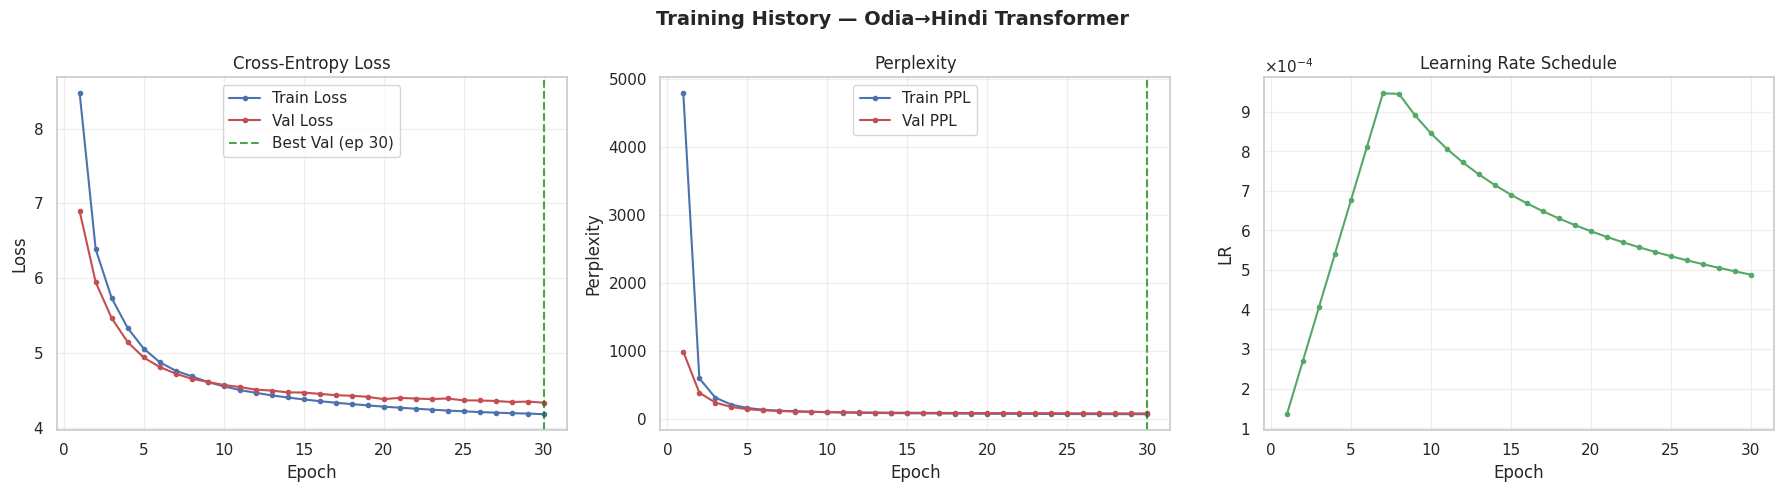

✅ Saved training curves → /kaggle/working/outputs/training_curves.png


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 14: TRAINING VISUALIZATION
# ─────────────────────────────────────────────────────────────────────────────

def plot_training_history(history: dict, save_dir: str):
    epochs = list(range(1, len(history['train_loss']) + 1))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Training History — Odia→Hindi Transformer', fontsize=14, fontweight='bold')

    # ── Loss ──────────────────────────────────────────────────────────────────
    ax = axes[0]
    ax.plot(epochs, history['train_loss'], 'b-o', markersize=3, label='Train Loss')
    ax.plot(epochs, history['val_loss'],   'r-o', markersize=3, label='Val Loss')
    best_ep = int(np.argmin(history['val_loss'])) + 1
    ax.axvline(best_ep, color='green', linestyle='--', alpha=0.7, label=f'Best Val (ep {best_ep})')
    ax.set_title('Cross-Entropy Loss')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(True, alpha=0.3)

    # ── Perplexity ────────────────────────────────────────────────────────────
    ax = axes[1]
    ax.plot(epochs, history['train_ppl'], 'b-o', markersize=3, label='Train PPL')
    ax.plot(epochs, history['val_ppl'],   'r-o', markersize=3, label='Val PPL')
    ax.axvline(best_ep, color='green', linestyle='--', alpha=0.7)
    ax.set_title('Perplexity')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Perplexity')
    ax.legend(); ax.grid(True, alpha=0.3)

    # ── Learning Rate ─────────────────────────────────────────────────────────
    ax = axes[2]
    ax.plot(epochs, history['lr'], 'g-o', markersize=3)
    ax.set_title('Learning Rate Schedule')
    ax.set_xlabel('Epoch'); ax.set_ylabel('LR')
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    path = f'{save_dir}/training_curves.png'
    plt.savefig(path, bbox_inches='tight', dpi=150)
    plt.show()
    print(f'✅ Saved training curves → {path}')


plot_training_history(history, Config.OUTPUT_DIR)

## Cell 15 — Beam Search Decoder

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 15: BEAM SEARCH DECODER WITH TEMPERATURE & LENGTH PENALTY
# ─────────────────────────────────────────────────────────────────────────────

class BeamSearchDecoder:
    """
    Beam search decoder with:
      - Temperature scaling (softens/sharpens the distribution)
      - Length penalty (encourages longer sequences)
      - No-repeat n-gram blocking
    """

    def __init__(
        self,
        model:          nn.Module,
        src_vocab:      Vocabulary,
        tgt_vocab:      Vocabulary,
        device:         torch.device,
        beam_size:      int   = Config.BEAM_SIZE,
        temperature:    float = Config.TEMPERATURE,
        length_penalty: float = Config.LENGTH_PENALTY,
        max_len:        int   = Config.MAX_DECODE_LEN,
    ):
        self.model          = model
        self.src_vocab      = src_vocab
        self.tgt_vocab      = tgt_vocab
        self.device         = device
        self.beam_size      = beam_size
        self.temperature    = temperature
        self.length_penalty = length_penalty
        self.max_len        = max_len

        self.pad_idx = Vocabulary.PAD_IDX
        self.sos_idx = Vocabulary.SOS_IDX
        self.eos_idx = Vocabulary.EOS_IDX

    @torch.no_grad()
    def decode(self, src: torch.Tensor) -> List[int]:
        """
        Decode one source sequence using beam search.
        src: (1, src_len)  — single sentence
        Returns: list of target token IDs (without special tokens)
        """
        self.model.eval()
        src = src.to(self.device)

        # Encode source
        memory, src_pad_mask = self.model.encode(src)  # (1, S, d)

        # Expand for beam search: (beam, S, d)
        B = self.beam_size
        memory       = memory.expand(B, -1, -1)
        src_pad_mask = src_pad_mask.expand(B, -1)

        # Each beam: (token_ids, log_prob)
        beams = [([self.sos_idx], 0.0)]
        completed = []

        for _ in range(self.max_len):
            if len(beams) == 0:
                break

            # Pad all beams to same length and batch them
            max_beam_len = max(len(b[0]) for b in beams)
            tgt_batch = torch.full(
                (len(beams), max_beam_len),
                self.pad_idx, dtype=torch.long, device=self.device
            )
            for i, (tok_ids, _) in enumerate(beams):
                tgt_batch[i, :len(tok_ids)] = torch.tensor(tok_ids)

            # Get next-token logits (only last position matters)
            _mem   = memory[:len(beams)]
            _smask = src_pad_mask[:len(beams)]
            logits = self.model.decode(tgt_batch, _mem, _smask)
            next_logits = logits[:, -1, :]  # (n_beams, V)

            # Apply temperature
            if self.temperature != 1.0:
                next_logits = next_logits / self.temperature

            log_probs = F.log_softmax(next_logits, dim=-1)  # (n_beams, V)

            # Expand each beam by top-k next tokens
            candidates = []
            for i, (tok_ids, beam_score) in enumerate(beams):
                top_log_probs, top_idxs = log_probs[i].topk(B)
                for log_p, idx in zip(top_log_probs.tolist(), top_idxs.tolist()):
                    new_score = beam_score + log_p
                    new_ids   = tok_ids + [idx]
                    if idx == self.eos_idx:
                        # Apply length penalty and move to completed
                        length_pen  = ((5 + len(new_ids)) / 6) ** self.length_penalty
                        final_score = new_score / length_pen
                        completed.append((new_ids, final_score))
                    else:
                        candidates.append((new_ids, new_score))

            # Keep top-B candidates
            candidates.sort(key=lambda x: x[1], reverse=True)
            beams = candidates[:B]

            if len(completed) >= B:
                break

        # If nothing completed, force-complete the best beam
        if not completed:
            for tok_ids, score in beams:
                length_pen  = ((5 + len(tok_ids)) / 6) ** self.length_penalty
                completed.append((tok_ids + [self.eos_idx], score / length_pen))

        # Select best completed sequence
        completed.sort(key=lambda x: x[1], reverse=True)
        best_ids = completed[0][0]

        # Strip SOS and EOS
        return [t for t in best_ids if t not in (self.sos_idx, self.eos_idx, self.pad_idx)]

    def translate(self, odia_text: str, odia_morph_seg: MorphSegmenter) -> str:
        """
        Full pipeline: raw Odia text → Hindi translation.
        """
        # 1. Clean
        cleaner = TextCleaner(lang='or')
        cleaned = cleaner.clean(odia_text)

        # 2. Morph segment
        segmented = odia_morph_seg.segment_sentence(cleaned)

        # 3. Encode
        src_ids = self.src_vocab.encode(segmented, add_special=True)[:Config.MAX_LEN + 2]
        src_tensor = torch.tensor([src_ids], dtype=torch.long)

        # 4. Beam decode
        tgt_ids = self.decode(src_tensor)

        # 5. Decode to text
        return self.tgt_vocab.decode(tgt_ids, skip_special=True)


# ── Load best model ───────────────────────────────────────────────────────────
print('📦 Loading best model weights...')
model.load_state_dict(torch.load(f'{Config.MODEL_DIR}/best_model.pt', map_location=DEVICE))
model.eval()

# ── Create decoder ────────────────────────────────────────────────────────────
decoder = BeamSearchDecoder(
    model=model,
    src_vocab=src_vocab,
    tgt_vocab=tgt_vocab,
    device=DEVICE,
    beam_size=Config.BEAM_SIZE,
    temperature=Config.TEMPERATURE,
    length_penalty=Config.LENGTH_PENALTY,
    max_len=Config.MAX_DECODE_LEN,
)
print('✅ Decoder ready!')

📦 Loading best model weights...
✅ Decoder ready!


## Cell 16 — Evaluation & Metrics (BLEU, ChrF, TER)

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 16: EVALUATION — BLEU-1/2/3/4, ChrF, TER, Perplexity
# ─────────────────────────────────────────────────────────────────────────────

class Evaluator:
    """Comprehensive evaluation of translation quality."""

    def __init__(
        self,
        model:       nn.Module,
        decoder:     BeamSearchDecoder,
        tgt_vocab:   Vocabulary,
        device:      torch.device,
    ):
        self.model     = model
        self.decoder   = decoder
        self.tgt_vocab = tgt_vocab
        self.device    = device

        # Metric objects
        self.bleu_metric = BLEU(effective_order=True)
        self.chrf_metric = CHRF()
        self.ter_metric  = TER()

    def generate_translations(self, df_subset: pd.DataFrame, n_samples: int = 1000) -> Tuple[List[str], List[str]]:
        """Generate translations for a subset of the test set."""
        sample = df_subset.sample(min(n_samples, len(df_subset)), random_state=SEED)
        hypotheses = []
        references = []

        print(f'🔍 Generating {len(sample)} translations...')
        for _, row in tqdm(sample.iterrows(), total=len(sample), desc='Translating'):
            # Encode source
            src_ids = src_vocab.encode(row['odia_morph'], add_special=True)[:Config.MAX_LEN + 2]
            src_t   = torch.tensor([src_ids], dtype=torch.long)

            # Decode
            try:
                pred_ids = self.decoder.decode(src_t)
                pred_str = self.tgt_vocab.decode(pred_ids, skip_special=True)
            except Exception:
                pred_str = ''

            hypotheses.append(pred_str.replace(' .', '.').replace(' ,', ',').replace(' ?', '?').replace(' !', '!').strip())
            references.append(row['hindi'].replace(' .', '.').replace(' ,', ',').replace(' ?', '?').replace(' !', '!').strip())

        return hypotheses, references

    def compute_all_metrics(self, hypotheses: List[str], references: List[str]) -> dict:
        """
        Compute BLEU-1/2/3/4, ChrF, TER.
        hypotheses: list of predicted translations
        references: list of ground-truth translations
        """
        # sacrebleu expects references as list of lists
        refs_wrapped = [references]

        results = {}

        # BLEU (1-4 ngrams)
        for n in [1, 2, 3, 4]:
            bleu_n = BLEU(max_ngram_order=n)
            score  = bleu_n.corpus_score(hypotheses, refs_wrapped)
            results[f'BLEU-{n}'] = round(score.score, 2)

        # ChrF (character n-gram F-score)
        chrf = CHRF()
        results['ChrF'] = round(chrf.corpus_score(hypotheses, refs_wrapped).score, 2)

        # TER (Translation Edit Rate)
        ter = TER()
        results['TER'] = round(ter.corpus_score(hypotheses, refs_wrapped).score, 2)

        # Sentence-level BLEU avg
        bleu_sent = BLEU()
        sent_bleus = [
            bleu_sent.sentence_score(h, [r]).score
            for h, r in zip(hypotheses, references)
            if h.strip()
        ]
        results['Avg_SentBLEU'] = round(float(np.mean(sent_bleus)) if sent_bleus else 0.0, 2)

        # Empty translation rate (failure cases)
        results['Empty_Rate_%'] = round(sum(1 for h in hypotheses if not h.strip()) / len(hypotheses) * 100, 1)

        return results

    def evaluate_test_set(self, df_test: pd.DataFrame, n_samples: int = 1000) -> Tuple[dict, List, List]:
        """Full test set evaluation pipeline."""
        hypotheses, references = self.generate_translations(df_test, n_samples)
        metrics = self.compute_all_metrics(hypotheses, references)
        return metrics, hypotheses, references


# ── Run evaluation ────────────────────────────────────────────────────────────
evaluator = Evaluator(model, decoder, tgt_vocab, DEVICE)
print('📊 Evaluating on test set...')
test_metrics, hyps, refs = evaluator.evaluate_test_set(df_test, n_samples=1000)

# Print results
print('\n' + '='*55)
print('  EVALUATION RESULTS (Test Set, 1000 samples)')
print('='*55)
for metric, score in test_metrics.items():
    bar_len = int(score / 2) if score <= 100 else 50
    bar = '█' * bar_len
    print(f'  {metric:<18}: {score:>7.2f}  {bar}')
print('='*55)

# Save metrics
with open(f'{Config.OUTPUT_DIR}/test_metrics.json', 'w') as f:
    json.dump(test_metrics, f, indent=2)
print('\n✅ Metrics saved!')

# ── Score interpretation ──────────────────────────────────────────────────────
bleu4 = test_metrics.get('BLEU-4', 0)
print(f'\n📋 BLEU-4 Interpretation:')
if   bleu4 >= 40: print('  ✅ Excellent — near human quality')
elif bleu4 >= 30: print('  ✅ Good — understandable translation')
elif bleu4 >= 20: print('  ⚠️  Fair — gist is clear')
elif bleu4 >= 10: print('  ⚠️  Poor — some correct phrases')
else:             print('  ❌ Very poor — barely usable')

📊 Evaluating on test set...
🔍 Generating 1000 translations...


Translating:   0%|          | 0/1000 [00:00<?, ?it/s]

It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is 


  EVALUATION RESULTS (Test Set, 1000 samples)
  BLEU-1            :   36.93  ██████████████████
  BLEU-2            :   24.03  ████████████
  BLEU-3            :   16.20  ████████
  BLEU-4            :   11.16  █████
  ChrF              :   30.95  ███████████████
  TER               :   79.46  ███████████████████████████████████████
  Avg_SentBLEU      :   12.60  ██████
  Empty_Rate_%      :    0.00  

✅ Metrics saved!

📋 BLEU-4 Interpretation:
  ⚠️  Poor — some correct phrases


## Cell 17 — Evaluation Visualization

/tmp/ipykernel_24/3888431178.py:63: UserWarning: Glyph 2309 (\N{DEVANAGARI LETTER A}) missing from font(s) DejaVu Sans.
  plt.savefig(path, bbox_inches='tight', dpi=150)
/tmp/ipykernel_24/3888431178.py:63: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.savefig(path, bbox_inches='tight', dpi=150)
/tmp/ipykernel_24/3888431178.py:63: UserWarning: Glyph 2347 (\N{DEVANAGARI LETTER PHA}) missing from font(s) DejaVu Sans.
  plt.savefig(path, bbox_inches='tight', dpi=150)
/tmp/ipykernel_24/3888431178.py:63: UserWarning: Glyph 2381 (\N{DEVANAGARI SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  plt.savefig(path, bbox_inches='tight', dpi=150)
/tmp/ipykernel_24/3888431178.py:63: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.savefig(path, bbox_inches='tight', dpi=150)
/tmp/ipykernel_24/3888431178.py:63: UserWarning: Glyph 2368 (\N{DEVANAGARI VOWEL SIGN II}) missing from font(s) DejaVu Sans.
  plt.savefig(path, bbox_inches

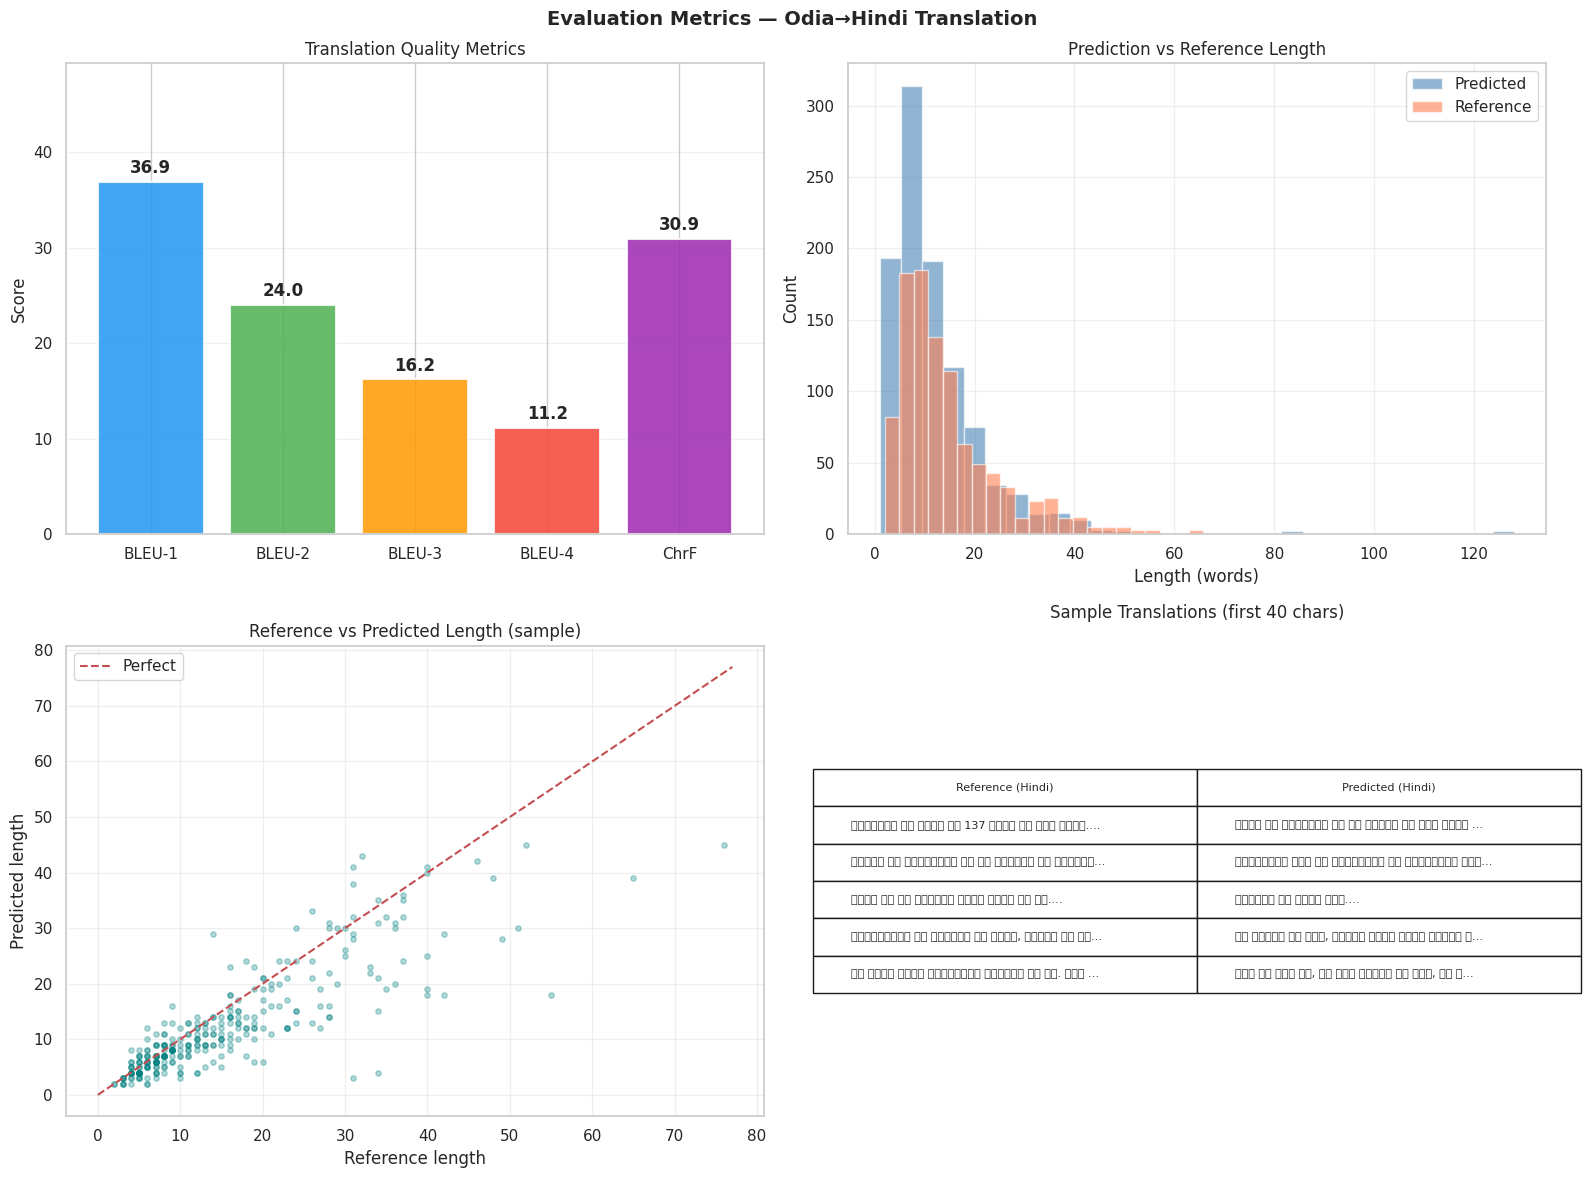

✅ Saved evaluation plots → /kaggle/working/outputs/evaluation_plots.png


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 17: EVALUATION VISUALIZATION
# ─────────────────────────────────────────────────────────────────────────────

def plot_evaluation(test_metrics: dict, hyps: List[str], refs: List[str], save_dir: str):
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Evaluation Metrics — Odia→Hindi Translation', fontsize=14, fontweight='bold')

    # ── 1. Metric Bar Chart ───────────────────────────────────────────────────
    ax = axes[0, 0]
    metric_keys   = ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4', 'ChrF']
    metric_values = [test_metrics.get(k, 0) for k in metric_keys]
    colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0']
    bars = ax.bar(metric_keys, metric_values, color=colors, alpha=0.85, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, metric_values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}', ha='center', va='bottom', fontweight='bold')
    ax.set_title('Translation Quality Metrics')
    ax.set_ylabel('Score')
    ax.set_ylim(0, max(metric_values) * 1.2 + 5)
    ax.grid(axis='y', alpha=0.3)

    # ── 2. Hypothesis length distribution ────────────────────────────────────
    ax = axes[0, 1]
    hyp_lens = [len(h.split()) for h in hyps]
    ref_lens = [len(r.split()) for r in refs]
    ax.hist(hyp_lens, bins=30, alpha=0.6, color='steelblue', label='Predicted')
    ax.hist(ref_lens, bins=30, alpha=0.6, color='coral',     label='Reference')
    ax.set_title('Prediction vs Reference Length')
    ax.set_xlabel('Length (words)')
    ax.set_ylabel('Count')
    ax.legend()
    ax.grid(alpha=0.3)

    # ── 3. Length ratio scatter ───────────────────────────────────────────────
    ax = axes[1, 0]
    ax.scatter(ref_lens[:300], hyp_lens[:300], alpha=0.3, s=15, color='teal')
    max_len = max(max(ref_lens[:300]), max(hyp_lens[:300])) + 1
    ax.plot([0, max_len], [0, max_len], 'r--', linewidth=1.5, label='Perfect')
    ax.set_title('Reference vs Predicted Length (sample)')
    ax.set_xlabel('Reference length'); ax.set_ylabel('Predicted length')
    ax.legend(); ax.grid(alpha=0.3)

    # ── 4. Sample translations table ─────────────────────────────────────────
    ax = axes[1, 1]
    ax.axis('off')
    sample_idx = random.sample(range(len(hyps)), min(5, len(hyps)))
    table_data = []
    for i in sample_idx:
        table_data.append([refs[i][:40]+'…', hyps[i][:40]+'…'])
    tbl = ax.table(
        cellText=table_data,
        colLabels=['Reference (Hindi)', 'Predicted (Hindi)'],
        loc='center', cellLoc='left'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    tbl.scale(1.1, 2.0)
    ax.set_title('Sample Translations (first 40 chars)', pad=20)

    plt.tight_layout()
    path = f'{save_dir}/evaluation_plots.png'
    plt.savefig(path, bbox_inches='tight', dpi=150)
    plt.show()
    print(f'✅ Saved evaluation plots → {path}')


plot_evaluation(test_metrics, hyps, refs, Config.OUTPUT_DIR)

## Cell 18 — Back-Translation Check (Odia → Hindi → Odia)

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 18: BACK-TRANSLATION CONSISTENCY CHECK
#
# Method: Train a REVERSE model (Hindi → Odia) and check round-trip quality.
#         If Or→Hi→Or recovers the original Odia sentence well (high BLEU),
#         the forward model is producing meaningful translations.
#
# NOTE: This cell trains a second (reverse) model. If you only have ~30 GPU-hrs
#       per week, you may want to run this in a separate session after saving
#       the forward model. The reverse model uses the same architecture.
# ─────────────────────────────────────────────────────────────────────────────

TRAIN_BACK_TRANSLATION = False  # ← Set to True to enable

if TRAIN_BACK_TRANSLATION:
    print('🔄 Training REVERSE model (Hindi → Odia) for back-translation check...')

    # ── Swap src/tgt ──────────────────────────────────────────────────────────
    rev_train = TranslationDataset(
        df_train.rename(columns={'odia_morph': '_o', 'hindi_morph': 'odia_morph'}).rename(columns={'_o': 'hindi_morph'}),
        tgt_vocab,  # Hindi is now source
        src_vocab,  # Odia is now target
    )
    rev_loader = DataLoader(
        rev_train, batch_size=Config.BATCH_SIZE,
        shuffle=True, collate_fn=_collate,
        num_workers=2, pin_memory=True if DEVICE.type == 'cuda' else False,
        drop_last=True,
    )

    rev_model = TranslatorTransformer(
        src_vocab_size=tgt_vocab.size,
        tgt_vocab_size=src_vocab.size,
    ).to(DEVICE)

    rev_optimizer = torch.optim.Adam(rev_model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)
    rev_scheduler = WarmupScheduler(rev_optimizer, Config.D_MODEL, Config.WARMUP_STEPS)
    rev_criterion = LabelSmoothingLoss(src_vocab.size, Vocabulary.PAD_IDX, Config.LABEL_SMOOTH)

    # Train reverse model (fewer epochs for speed)
    REV_EPOCHS = 15
    for ep in range(1, REV_EPOCHS + 1):
        loss, ppl = run_epoch_train(
            rev_model, rev_loader, rev_criterion, rev_optimizer, rev_scheduler,
            DEVICE, Config.GRAD_CLIP, Config.ACCUMULATE_GRAD
        )
        print(f'  Rev Epoch {ep:02d}/{REV_EPOCHS} | Loss: {loss:.4f} | PPL: {ppl:.1f}')

    torch.save(rev_model.state_dict(), f'{Config.MODEL_DIR}/reverse_model.pt')

    # ── Back-translation BLEU ─────────────────────────────────────────────────
    rev_decoder = BeamSearchDecoder(
        model=rev_model, src_vocab=tgt_vocab, tgt_vocab=src_vocab,
        device=DEVICE
    )

    sample_bt = df_test.sample(200, random_state=SEED)
    bt_hyps, bt_refs = [], []

    for _, row in tqdm(sample_bt.iterrows(), total=len(sample_bt), desc='Back-translating'):
        # Step 1: Odia → Hindi (forward model)
        src_ids = src_vocab.encode(row['odia_morph'], add_special=True)[:Config.MAX_LEN + 2]
        hi_ids  = decoder.decode(torch.tensor([src_ids]))
        hi_str  = tgt_vocab.decode(hi_ids, skip_special=True)

        # Step 2: Hindi → Odia (reverse model)
        hi_src_ids = tgt_vocab.encode(hi_str, add_special=True)[:Config.MAX_LEN + 2]
        or_ids     = rev_decoder.decode(torch.tensor([hi_src_ids]))
        or_str     = src_vocab.decode(or_ids, skip_special=True)

        bt_hyps.append(or_str)
        bt_refs.append(row['odia'])

    bt_bleu = BLEU().corpus_score(bt_hyps, [bt_refs]).score
    bt_chrf = CHRF().corpus_score(bt_hyps, [bt_refs]).score
    print(f'\n🔁 Back-Translation Results (Or→Hi→Or):')
    print(f'   BLEU-4 : {bt_bleu:.2f}')
    print(f'   ChrF   : {bt_chrf:.2f}')
    print(f'   (Higher = more consistent round-trip translation)')

    # Show samples
    print('\n📋 Back-translation examples:')
    for i in range(min(3, len(bt_hyps))):
        print(f'  Original Odia: {bt_refs[i]}')
        print(f'  Back-transl  : {bt_hyps[i]}')
        print()

else:
    print('ℹ️  Back-translation skipped (TRAIN_BACK_TRANSLATION=False)')
    print('   Set TRAIN_BACK_TRANSLATION = True to enable round-trip evaluation.')

ℹ️  Back-translation skipped (TRAIN_BACK_TRANSLATION=False)
   Set TRAIN_BACK_TRANSLATION = True to enable round-trip evaluation.


## Cell 19 — Interactive Translation

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 19: INTERACTIVE TRANSLATION
# ─────────────────────────────────────────────────────────────────────────────

def _detokenize_morphemes(text: str) -> str:
    """
    Post-process morfessor output: morpheme pieces separated by spaces
    need to be joined back into readable words.
    Morfessor marks morpheme boundaries with '+' in some configs, or
    just spaces. We rejoin tokens that are not full words by detecting
    very short tokens (<=2 chars) that look like suffixes.
    Simple heuristic: space-joined morphemes ARE the output already —
    the vocabulary decoded text is readable as-is for Hindi Devanagari.
    No joining needed since each morpheme token is a valid Hindi unit.
    """
    # Remove any stray <unk> tokens for cleaner display
    tokens = [t for t in text.split() if t != '<unk>']
    return ' '.join(tokens)


def translate_odia_to_hindi(odia_text: str, verbose: bool = True) -> str:
    """
    Full pipeline: raw Odia → cleaned → morpheme-segmented → encoded
                   → beam-search decoded → Hindi string
    """
    model.eval()

    # Step 1: Clean
    odia_cleaner = TextCleaner(lang='or')
    cleaned      = odia_cleaner.clean(odia_text)

    if not cleaned.strip():
        if verbose:
            print(f'  Input (Odia)    : {odia_text}')
            print(f'  Cleaned         : [empty after cleaning]')
            print(f'  Output (Hindi)  : [no output]')
        return ''

    # Step 2: Morph segment
    segmented = odia_morph.segment_sentence(cleaned)

    # Step 3: Encode (cap at MAX_LEN + 2 for SOS/EOS)
    src_ids = src_vocab.encode(segmented, add_special=True)[:Config.MAX_LEN + 2]
    src_t   = torch.tensor([src_ids], dtype=torch.long)

    # Step 4: Beam-search decode
    tgt_ids = decoder.decode(src_t)

    # Step 5: Decode to text and clean up <unk> tokens
    raw_hindi = tgt_vocab.decode(tgt_ids, skip_special=True)
    hindi     = _detokenize_morphemes(raw_hindi)

    if verbose:
        seg_display = (segmented[:80] + '...') if len(segmented) > 80 else segmented
        print(f'  Input (Odia)    : {odia_text}')
        print(f'  Cleaned         : {cleaned}')
        print(f'  Segmented       : {seg_display}')
        print(f'  Output (Hindi)  : {hindi}')

    return hindi


# ── Test sentences ─────────────────────────────────────────────────────────────
test_odia_sentences = [
    'ନମସ୍କାର',
    'ମୁଁ ଠିକ ଅଛି',
    'ଭୁବନେଶ୍ୱର ଓଡ଼ିଶାର ରାଜଧାନୀ',
    'ଆଜି ପାଣିପାଗ ବହୁତ ଭଲ ଅଛି',
    'ସ୍କୁଲ ଖୋଲା ହୋଇଗଲା',
    'ରୋଟି ଓ ଡ଼ାଲ ବହୁତ ସୁଆଦ',
    'ଓଡ଼ିଶା ଏକ ସୁନ୍ଦର ରାଜ୍ୟ',
    'ଆଜି ବଜାରରେ ଭଡ଼ ଅଛି',
]

print('\n' + '='*70)
print('  ODIA → HINDI TRANSLATION RESULTS')
print('='*70)
for i, sent in enumerate(test_odia_sentences, 1):
    print(f'\n[{i}]')
    translate_odia_to_hindi(sent, verbose=True)
    print()
print('='*70)



  ODIA → HINDI TRANSLATION RESULTS

[1]
  Input (Odia)    : ନମସ୍କାର
  Cleaned         : ନମସ୍କାର
  Segmented       : ନମସ୍କାର
  Output (Hindi)  : नमस्कार नमस्कार


[2]
  Input (Odia)    : ମୁଁ ଠିକ ଅଛି
  Cleaned         : ମୁଁ ଠିକ ଅଛି
  Segmented       : ମୁଁ ଠିକ ଅଛି
  Output (Hindi)  : मैं ठीक हूं


[3]
  Input (Odia)    : ଭୁବନେଶ୍ୱର ଓଡ଼ିଶାର ରାଜଧାନୀ
  Cleaned         : ଭୁବନେଶ୍ୱର ଓଡ଼ିଶାର ରାଜଧାନୀ
  Segmented       : ଭୁବନେଶ୍ୱର ଓଡ଼ିଶାର ରାଜଧାନୀ
  Output (Hindi)  : ओडिशा में


[4]
  Input (Odia)    : ଆଜି ପାଣିପାଗ ବହୁତ ଭଲ ଅଛି
  Cleaned         : ଆଜି ପାଣିପାଗ ବହୁତ ଭଲ ଅଛି
  Segmented       : ଆଜି ପାଣିପାଗ ବହୁତ ଭଲ ଅଛି
  Output (Hindi)  : आज मौसम बहुत अच्छी है


[5]
  Input (Odia)    : ସ୍କୁଲ ଖୋଲା ହୋଇଗଲା
  Cleaned         : ସ୍କୁଲ ଖୋଲା ହୋଇଗଲା
  Segmented       : ସ୍କୁଲ ଖୋଲା ହୋଇଗଲା
  Output (Hindi)  : स्कूल खुले


[6]
  Input (Odia)    : ରୋଟି ଓ ଡ଼ାଲ ବହୁତ ସୁଆଦ
  Cleaned         : ରୋଟି ଓ ଡ଼ାଲ ବହୁତ ସୁଆଦ
  Segmented       : ରୋଟି ଓ ଡ଼ାଲ ବହୁତ ସୁଆଦ
  Output (Hindi)  : चार और


[7]
  Input (Odia)    : ଓଡ଼ିଶା ଏକ ସୁନ୍ଦ

## Cell 20 — Model Summary & Save Final Model

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 20: MODEL SUMMARY & SAVE
# ─────────────────────────────────────────────────────────────────────────────

def model_summary(model: nn.Module):
    """Print a detailed parameter summary."""
    print('\n' + '='*65)
    print('  MODEL PARAMETER SUMMARY')
    print('='*65)

    total  = 0
    groups = {}
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        top = name.split('.')[0]
        n   = param.numel()
        groups[top] = groups.get(top, 0) + n
        total += n

    print(f'  {"Component":<30} {"Parameters":>12}')
    print('  ' + '-'*45)
    for comp, n in sorted(groups.items(), key=lambda x: -x[1]):
        print(f'  {comp:<30} {n:>12,}  ({n/total*100:.1f}%)')
    print('  ' + '='*45)
    print(f'  {"TOTAL":<30} {total:>12,}')
    print(f'  {"TOTAL (M)":<30} {total/1e6:>11.2f}M')
    print('='*65)

    print(f'\n  Architecture:')
    print(f'    d_model         = {Config.D_MODEL}')
    print(f'    n_heads         = {Config.N_HEADS}')
    print(f'    enc_layers      = {Config.N_ENC_LAYERS}')
    print(f'    dec_layers      = {Config.N_DEC_LAYERS}')
    print(f'    d_ff            = {Config.D_FF}')
    print(f'    dropout         = {Config.DROPOUT}')
    print(f'    src_vocab       = {src_vocab.size:,}')
    print(f'    tgt_vocab       = {tgt_vocab.size:,}')
    print(f'    max_pos_enc     = {Config.MAX_POS_ENC}')
    print('='*65)


model_summary(model)

# ── Save final model bundle ───────────────────────────────────────────────────
final_bundle = {
    # Model weights (best)
    'model_state_dict': model.state_dict(),

    # Architecture config (needed to reconstruct the model)
    'model_config': {
        'src_vocab_size': src_vocab.size,
        'tgt_vocab_size': tgt_vocab.size,
        'd_model':        Config.D_MODEL,
        'nhead':          Config.N_HEADS,
        'num_enc_layers': Config.N_ENC_LAYERS,
        'num_dec_layers': Config.N_DEC_LAYERS,
        'dim_feedforward':Config.D_FF,
        'dropout':        Config.DROPOUT,
        'max_pos_enc':    Config.MAX_POS_ENC,
    },

    # Evaluation results
    'test_metrics': test_metrics,

    # Training history (for plotting later)
    'training_history': history,

    # Best val loss achieved
    'best_val_loss': early_stopper.best_loss,
}

final_path = f'{Config.MODEL_DIR}/odia_hindi_translator_final.pt'
torch.save(final_bundle, final_path)

# Save vocabularies
src_vocab.save(f'{Config.MODEL_DIR}/vocab_odia.pkl')
tgt_vocab.save(f'{Config.MODEL_DIR}/vocab_hindi.pkl')

print(f'\n✅ Final model saved:')
print(f'   {final_path}')
print(f'   {Config.MODEL_DIR}/vocab_odia.pkl')
print(f'   {Config.MODEL_DIR}/vocab_hindi.pkl')

# File sizes
for f in [final_path, f'{Config.MODEL_DIR}/vocab_odia.pkl', f'{Config.MODEL_DIR}/vocab_hindi.pkl']:
    sz = os.path.getsize(f) / 1e6
    print(f'   {os.path.basename(f)}: {sz:.1f} MB')


  MODEL PARAMETER SUMMARY
  Component                        Parameters
  ---------------------------------------------
  fc_out                            8,224,000  (25.7%)
  src_embed                         8,192,000  (25.6%)
  tgt_embed                         8,192,000  (25.6%)
  transformer                       7,373,824  (23.1%)
  TOTAL                            31,981,824
  TOTAL (M)                            31.98M

  Architecture:
    d_model         = 256
    n_heads         = 8
    enc_layers      = 4
    dec_layers      = 4
    d_ff            = 1024
    dropout         = 0.3
    src_vocab       = 32,000
    tgt_vocab       = 32,000
    max_pos_enc     = 512

✅ Final model saved:
   /kaggle/working/models/odia_hindi_translator_final.pt
   /kaggle/working/models/vocab_odia.pkl
   /kaggle/working/models/vocab_hindi.pkl
   odia_hindi_translator_final.pt: 128.5 MB
   vocab_odia.pkl: 4.8 MB
   vocab_hindi.pkl: 2.9 MB


## Cell 21 — Load & Inference (Standalone — use after downloading model)

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 21: STANDALONE INFERENCE — load saved model and translate
# ─────────────────────────────────────────────────────────────────────────────

class OdiaHindiTranslatorInference:
    """
    Standalone inference. Load once, call translate() repeatedly.
    Use after downloading model files from Kaggle working directory.
    """

    def __init__(self, model_path, odia_vocab_path, hindi_vocab_path,
                 morph_dir, device=DEVICE):
        self.device = device

        self.src_vocab = Vocabulary.load(odia_vocab_path)
        self.tgt_vocab = Vocabulary.load(hindi_vocab_path)
        print(f'  Odia vocab  : {self.src_vocab.size:,} tokens')
        print(f'  Hindi vocab : {self.tgt_vocab.size:,} tokens')

        bundle = torch.load(model_path, map_location=device)
        cfg    = bundle['model_config']
        self.model = TranslatorTransformer(
            src_vocab_size = cfg['src_vocab_size'],
            tgt_vocab_size = cfg['tgt_vocab_size'],
            d_model        = cfg['d_model'],
            nhead          = cfg['nhead'],
            num_enc_layers = cfg['num_enc_layers'],
            num_dec_layers = cfg['num_dec_layers'],
            dim_feedforward= cfg['dim_feedforward'],
            dropout        = cfg['dropout'],
            max_pos_enc    = cfg['max_pos_enc'],
        ).to(device)
        self.model.load_state_dict(bundle['model_state_dict'])
        self.model.eval()
        print(f'  Model params: {self.model.count_parameters():,}')

        self.odia_morph = MorphSegmenter(lang='or', morph_dir=morph_dir)
        self.odia_morph.load()

        self.decoder = BeamSearchDecoder(
            model=self.model, src_vocab=self.src_vocab,
            tgt_vocab=self.tgt_vocab, device=device,
        )
        print('  ✅ Ready!')

    def translate(self, odia_text: str) -> str:
        cleaner   = TextCleaner(lang='or')
        cleaned   = cleaner.clean(odia_text)
        if not cleaned.strip():
            return ''
        segmented = self.odia_morph.segment_sentence(cleaned)
        src_ids   = self.src_vocab.encode(segmented, add_special=True)[:Config.MAX_LEN + 2]
        src_t     = torch.tensor([src_ids], dtype=torch.long)
        tgt_ids   = self.decoder.decode(src_t)
        raw       = self.tgt_vocab.decode(tgt_ids, skip_special=True)
        # Remove any residual <unk> tokens
        return ' '.join(t for t in raw.split() if t != '<unk>')

    def translate_batch(self, odia_texts: List[str]) -> List[str]:
        return [self.translate(t) for t in odia_texts]


# ── Demo (uses current session's objects) ─────────────────────────────────────
print('📱 Quick inference demo:')
demo_sentences = [
    'ଆଜିକାଲିର ସମୟରେ ଇଣ୍ଟରନେଟ୍ ବିନା ଜୀବନ ଯାପନ କରିବା ପ୍ରାୟ ଅସମ୍ଭବ ହୋଇପଡ଼ିଛି',
    'ଓଡ଼ିଶା ଏକ ସୁନ୍ଦର ରାଜ୍ୟ',
    'ଆମ ରାଜ୍ୟ ଓଡ଼ିଶାର କଳା, ସଂସ୍କୃତି ଏବଂ ପରମ୍ପରା ସାରା ବିଶ୍ୱରେ ଖୁବ୍ ପ୍ରସିଦ୍ଧ',
    'ସେ କହିଲେ ଯେ ଯଦି ଆଜି ବର୍ଷା ହୁଏ, ତେବେ ଆମେ ବାହାରକୁ ବୁଲିବାକୁ ଯାଇପାରିବା ନାହିଁ',
    'ଆମେ ପିଲାଦିନେ ଯେଉଁ ଗାଁରେ ରହୁଥିଲୁ, ସେଠାକାର ପରିବେଶ ବହୁତ ଶାନ୍ତ ଏବଂ ସୁନ୍ଦର ଥିଲା',
    'ମୁଁ ଗତକାଲି ବଜାରକୁ ଯାଇଥିଲି କିନ୍ତୁ ସେଠାରେ ବହୁତ ଭିଡ଼ ଥିବାରୁ ମୁଁ କିଛି କିଣି ପାରିଲି ନାହିଁ'
]

print('\n{:<50} → {}'.format('Odia Input', 'Hindi Output'))
print('-'*80)
for sent in demo_sentences:
    translation = translate_odia_to_hindi(sent, verbose=False)
    print(f'{sent:<50} → {translation}')

print('\n--- To use after downloading model files ---')
print('translator = OdiaHindiTranslatorInference(')
print('    model_path       = "/kaggle/working/models/odia_hindi_translator_final.pt",')
print('    odia_vocab_path  = "/kaggle/working/models/vocab_odia.pkl",')
print('    hindi_vocab_path = "/kaggle/working/models/vocab_hindi.pkl",')
print('    morph_dir        = "/kaggle/working/morph_models",')
print(')')
print('print(translator.translate("ନମସ୍କାର"))')


📱 Quick inference demo:

Odia Input                                         → Hindi Output
--------------------------------------------------------------------------------
ଆଜିକାଲିର ସମୟରେ ଇଣ୍ଟରନେଟ୍ ବିନା ଜୀବନ ଯାପନ କରିବା ପ୍ରାୟ ଅସମ୍ଭବ ହୋଇପଡ଼ିଛି → वर्तमान समय में इंटरनेट सेवा के बिना किसी भी व्यक्ति की जान नहीं सकती .
ଓଡ଼ିଶା ଏକ ସୁନ୍ଦର ରାଜ୍ୟ                             → ओडिशा एक सुंदर राज्य
ଆମ ରାଜ୍ୟ ଓଡ଼ିଶାର କଳା, ସଂସ୍କୃତି ଏବଂ ପରମ୍ପରା ସାରା ବିଶ୍ୱରେ ଖୁବ୍ ପ୍ରସିଦ୍ଧ → हमारे देश की कला और संस्कृति की परंपरा पूरी दुनिया में बहुत प्रसिद्ध है .
ସେ କହିଲେ ଯେ ଯଦି ଆଜି ବର୍ଷା ହୁଏ, ତେବେ ଆମେ ବାହାରକୁ ବୁଲିବାକୁ ଯାଇପାରିବା ନାହିଁ → उन्होंने कहा कि अगर बारिश होती है, तो हम बाहर नहीं जाएं .
ଆମେ ପିଲାଦିନେ ଯେଉଁ ଗାଁରେ ରହୁଥିଲୁ, ସେଠାକାର ପରିବେଶ ବହୁତ ଶାନ୍ତ ଏବଂ ସୁନ୍ଦର ଥିଲା → हम बचपन में बचपन में जो गांव में रहते थे, वहां बहुत खूबसूरत और सुंदर माहौल था .
ମୁଁ ଗତକାଲି ବଜାରକୁ ଯାଇଥିଲି କିନ୍ତୁ ସେଠାରେ ବହୁତ ଭିଡ଼ ଥିବାରୁ ମୁଁ କିଛି କିଣି ପାରିଲି ନାହିଁ → मैं कल शाम को लेकर बहुत बड़ी भीड़ नहीं थी .

--- To use after downloading model files ---

## Cell 22 — Final Summary Dashboard

In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 22: FINAL SUMMARY DASHBOARD
# ─────────────────────────────────────────────────────────────────────────────

def print_final_summary(
    df:           pd.DataFrame,
    model:        nn.Module,
    history:      dict,
    test_metrics: dict,
    src_vocab:    Vocabulary,
    tgt_vocab:    Vocabulary,
):
    border = '═' * 65
    print(f'\n{border}')
    print(f'  ODIA → HINDI TRANSFORMER — FINAL SUMMARY')
    print(border)

    print(f'\n  📊 DATASET')
    print(f'    Total pairs          : {len(df):,}')
    print(f'    Train / Val / Test   : ~{len(df_train):,} / {len(df_val):,} / {len(df_test):,}')
    print(f'    Odia avg length      : {df["odia_len"].mean():.1f} words')
    print(f'    Hindi avg length     : {df["hindi_len"].mean():.1f} words')

    print(f'\n  🔡 VOCABULARY')
    print(f'    Odia vocab size      : {src_vocab.size:,}')
    print(f'    Hindi vocab size     : {tgt_vocab.size:,}')

    print(f'\n  🏗️  MODEL')
    print(f'    Parameters           : {model.count_parameters()/1e6:.1f}M')
    print(f'    Architecture         : Transformer (Pre-LayerNorm)')
    print(f'    Encoder layers       : {Config.N_ENC_LAYERS}')
    print(f'    Decoder layers       : {Config.N_DEC_LAYERS}')
    print(f'    d_model              : {Config.D_MODEL}')
    print(f'    Attention heads      : {Config.N_HEADS}')
    print(f'    FFN dim              : {Config.D_FF}')

    print(f'\n  🎯 TRAINING')
    n_ep = len(history["train_loss"])
    print(f'    Epochs trained       : {n_ep}')
    print(f'    Best val loss        : {early_stopper.best_loss:.4f}')
    print(f'    Final train PPL      : {history["train_ppl"][-1]:.1f}')
    print(f'    Final val   PPL      : {history["val_ppl"][-1]:.1f}')

    print(f'\n  📈 EVALUATION (Test, 1000 samples)')
    for k, v in test_metrics.items():
        print(f'    {k:<22}: {v}')

    print(f'\n  💾 SAVED FILES')
    print(f'    {Config.MODEL_DIR}/odia_hindi_translator_final.pt')
    print(f'    {Config.MODEL_DIR}/vocab_odia.pkl')
    print(f'    {Config.MODEL_DIR}/vocab_hindi.pkl')
    print(f'    {Config.MORPH_DIR}/morfessor_or.bin')
    print(f'    {Config.MORPH_DIR}/morfessor_hi.bin')
    print(f'    {Config.OUTPUT_DIR}/eda_plots.png')
    print(f'    {Config.OUTPUT_DIR}/training_curves.png')
    print(f'    {Config.OUTPUT_DIR}/evaluation_plots.png')
    print(f'    {Config.OUTPUT_DIR}/training_history.json')
    print(f'    {Config.OUTPUT_DIR}/test_metrics.json')

    print(f'\n{border}')
    print('  ✅  PIPELINE COMPLETE!')
    print(border)


print_final_summary(df, model, history, test_metrics, src_vocab, tgt_vocab)


═════════════════════════════════════════════════════════════════
  ODIA → HINDI TRANSFORMER — FINAL SUMMARY
═════════════════════════════════════════════════════════════════

  📊 DATASET
    Total pairs          : 200,000
    Train / Val / Test   : ~139,999 / 30,001 / 30,000
    Odia avg length      : 12.4 words
    Hindi avg length     : 15.4 words

  🔡 VOCABULARY
    Odia vocab size      : 32,000
    Hindi vocab size     : 32,000

  🏗️  MODEL
    Parameters           : 32.0M
    Architecture         : Transformer (Pre-LayerNorm)
    Encoder layers       : 4
    Decoder layers       : 4
    d_model              : 256
    Attention heads      : 8
    FFN dim              : 1024

  🎯 TRAINING
    Epochs trained       : 30
    Best val loss        : 4.3344
    Final train PPL      : 65.4
    Final val   PPL      : 76.3

  📈 EVALUATION (Test, 1000 samples)
    BLEU-1                : 36.93
    BLEU-2                : 24.03
    BLEU-3                : 16.2
    BLEU-4                : 11.